In [ ]:
# ─────────────────────────────────────────────
# INSTALACIÓN AUTOMÁTICA DE DEPENDENCIAS
# ─────────────────────────────────────────────

import subprocess
import sys

def instalar_si_falta(paquete, nombre_import=None):
    """
    Intenta importar un paquete. Si no existe, lo instala automáticamente.
    
    Args:
        paquete: nombre del paquete en pip (ej: 'scikit-learn')
        nombre_import: nombre para importar (ej: 'sklearn'). Si es None, usa 'paquete'
    """
    nombre_import = nombre_import or paquete
    try:
        __import__(nombre_import)
    except ImportError:
        print(f"📦 Instalando {paquete}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", paquete, "-q"])
        print(f"✅ {paquete} instalado correctamente")

# Instalar dependencias requeridas
dependencias = [
    ('pandas',          'pandas'),
    ('numpy',           'numpy'),
    ('nltk',            'nltk'),
    ('scikit-learn',    'sklearn'),
    ('scipy',           'scipy'),
    ('joblib',          'joblib'),
    ('matplotlib',      'matplotlib'),
    ('seaborn',         'seaborn'),
]

print("🔍 Verificando dependencias...\n")
for paquete, nombre_import in dependencias:
    instalar_si_falta(paquete, nombre_import)

print("\n✅ Todas las dependencias están disponibles\n")

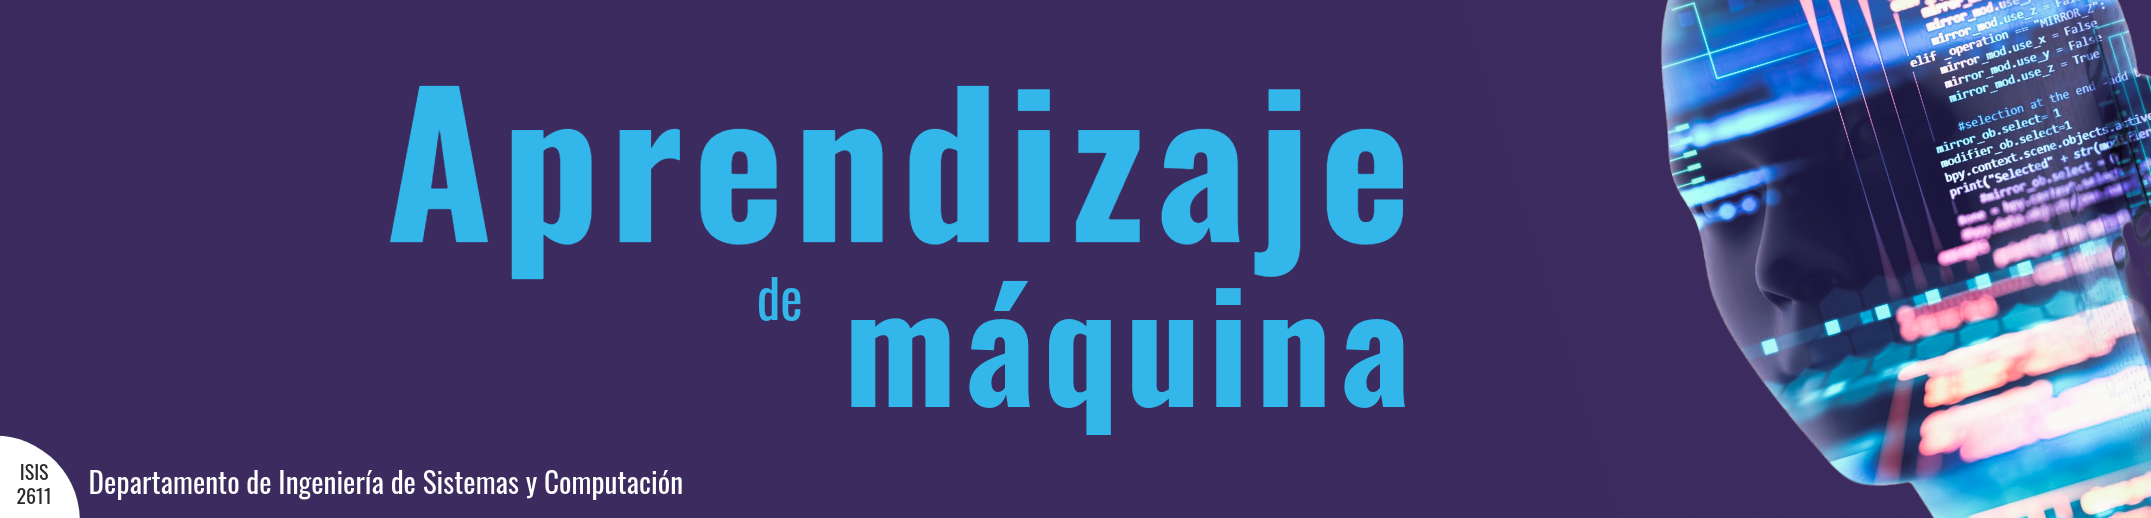


# Competencia — Aprendizaje de Máquina 2026-10
## Parte 1: Clasificación de Textos con Machine Learning Clásico

En este notebook abordaremos el problema de clasificación de textos según su **década de origen**. El objetivo principal es desarrollar un modelo capaz de predecir, dado un párrafo como entrada, la década en la que fue escrito. Trabajaremos exclusivamente con **técnicas clásicas de aprendizaje automático**, sin recurrir a redes neuronales ni arquitecturas profundas.

El dataset contiene textos históricos con señales temporales en el vocabulario, la sintaxis y la estructura del lenguaje. Por tanto, una parte importante del trabajo consiste en **representar adecuadamente el texto** antes de entrenar cualquier modelo. A lo largo del notebook podrás identificar las decisiones de preprocesamiento y su impacto en el desempeño del clasificador.

A continuación se presentan los bloques que se desarrollarán:

1. **Importación de librerías**
2. **Carga y exploración de los datos (EDA)**
3. **Preprocesamiento del texto**
4. **Partición de los datos**
5. **Representación del texto (vectorización)**
6. **Construcción del pipeline y modelos**
7. **Búsqueda de hiperparámetros**
8. **Evaluación y comparación de modelos**
9. **Análisis de importancia de features**
10. **Generación del archivo de respuesta para Kaggle**
11. **Guardado del modelo**

## 1. Importación de Librerías

En esta sección se importan todas las librerías necesarias para el desarrollo del notebook. Se organizan por categoría para facilitar su lectura:

- **Manejo de datos:** `pandas`, `numpy`
- **Procesamiento de texto:** `nltk` para tokenización, stopwords y stemming
- **Vectorización:** `CountVectorizer` y `TfidfVectorizer` de scikit-learn
- **Modelos clásicos:** Regresión Logística, Árbol de Decisión, Random Forest, Naive Bayes y KNN
- **Validación:** `StratifiedKFold` y `GridSearchCV` para búsqueda de hiperparámetros con datos balanceados
- **Métricas:** `f1_score` macro como métrica principal, dado que las clases (décadas) pueden estar desbalanceadas
- **Utilidades:** `scipy.sparse` para combinar representaciones, `joblib` para guardar el modelo entrenado

In [2]:
# ─────────────────────────────────────────────
# 1. IMPORTACIÓN DE LIBRERÍAS
# ─────────────────────────────────────────────

# Manejo de datos
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# ── Preprocesamiento de texto ──
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('punkt',        quiet=True)
nltk.download('punkt_tab',    quiet=True)
nltk.download('stopwords',    quiet=True)
nltk.download('wordnet',      quiet=True)

# ── Vectorización ──
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# ── Partición y validación ──
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
)

# ── Pipeline y transformadores ──
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer

# ── Modelos clásicos (Parte 1 — sin deep learning) ──
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import LinearSVC
from sklearn.naive_bayes     import MultinomialNB, ComplementNB
from sklearn.neighbors       import KNeighborsClassifier

# ── Métricas ──
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)

# ── Utilidades ──
from scipy.sparse import hstack, csr_matrix
import joblib

# ── Visualización ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("✅ Librerías cargadas correctamente.")

ModuleNotFoundError: No module named 'pandas'

## 2. Carga y Exploración de los Datos (EDA)

Antes de construir cualquier modelo, es fundamental entender la estructura y calidad de los datos. En esta sección verificamos:

- **Completitud:** presencia de valores nulos
- **Unicidad:** textos duplicados que podrían inflar el desempeño
- **Validez:** rangos coherentes en la variable objetivo `decade`
- **Balance de clases:** distribución de textos por década, ya que un desbalance significativo afecta la elección de la métrica y la estrategia de entrenamiento

El dataset contiene dos archivos:
- `train.csv`: textos etiquetados con su década de origen (variable `decade` expresada como los tres primeros dígitos del año, por ejemplo `157` para la década de 1570)
- `eval.csv`: textos sin etiqueta sobre los cuales se generarán las predicciones para Kaggle

In [ ]:
# ─────────────────────────────────────────────
# 2. CARGA Y EXPLORACIÓN DE DATOS (EDA)
# ─────────────────────────────────────────────

# ── Carga de archivos ──
df_train = pd.read_csv('./Data/train.csv')
df_eval  = pd.read_csv('./Data/eval.csv')

# Copia de trabajo para no modificar los datos originales
data = df_train.copy()

# ── Dimensiones ──
print(f"{'Train shape:':<20} {df_train.shape}")
print(f"{'Eval shape:':<20} {df_eval.shape}")

# ── Primeras filas ──
print("\n── Primeras filas del conjunto de entrenamiento ──")
display(df_train.head())

Train shape:         (31403, 2)
Eval shape:          (3490, 2)

── Primeras filas del conjunto de entrenamiento ──


,text,decade
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157
3,Caistro el M a y o r a i .] Del ape...,163
4,\nlos que panden macho ; y \notros en l...,166


El conjunto de entrenamiento cuenta con **31.403 textos** y 2 columnas (`text`, `decade`). El conjunto de evaluación tiene **3.490 textos**. Ambos datasets están correctamente estructurados.

In [ ]:
# ─────────────────────────────────────────────
# 2.1 Revisión de calidad
# ─────────────────────────────────────────────
print("\n── Tipos de datos ──")
print(df_train.dtypes)

print("\n── Valores nulos por columna ──")
print(df_train.isnull().sum())

print("\n── Textos duplicados ──")
n_dup = df_train['text'].duplicated().sum()
print(f"Duplicados en 'text': {n_dup}")


── Tipos de datos ──
text      object
decade     int64
dtype: object

── Valores nulos por columna ──
text      0
decade    0
dtype: int64

── Textos duplicados ──
Duplicados en 'text': 51


No hay valores nulos en ninguna columna. Se detectaron **51 textos duplicados** (<0.2% del total), los cuales serán eliminados en preprocesamiento para evitar que el mismo texto aparezca en entrenamiento y validación simultáneamente. La variable `decade` cubre desde **150** (década de 1500) hasta **188** (década de 1880), con **39 clases únicas**, confirmando que estamos ante un problema de **clasificación multiclase** de alta granularidad.

In [ ]:
# ─────────────────────────────────────────────
# 2.2 Distribución de clases
# ─────────────────────────────────────────────
decade_counts = df_train['decade'].value_counts().sort_index()

print("\n── Distribución de décadas ──")
print(decade_counts.to_string())

print(f"\nNúmero de clases únicas: {df_train['decade'].nunique()}")
print(f"Década más antigua:      {df_train['decade'].min()}")
print(f"Década más reciente:     {df_train['decade'].max()}")


── Distribución de décadas ──
decade
150    786
151    812
152    785
153    775
154    830
155    836
156    792
157    827
158    778
159    802
160    848
161    787
162    808
163    827
164    804
165    814
166    779
167    831
168    822
169    771
170    833
171    816
172    842
173    802
174    807
175    817
176    754
177    782
178    831
179    809
180    825
181    795
182    808
183    794
184    802
185    803
186    773
187    787
188    809

Número de clases únicas: 39
Década más antigua:      150
Década más reciente:     188


La distribución de textos por década es **notablemente uniforme**: todas las clases tienen entre 750 y 850 ejemplos, sin ninguna categoría dominante ni subrepresentada. Esto es favorable para el entrenamiento, aunque con 39 clases el problema sigue siendo desafiante. Usaremos `f1_macro` como métrica principal para tratar todas las décadas por igual, y `stratify=y` en la partición para preservar esta distribución.

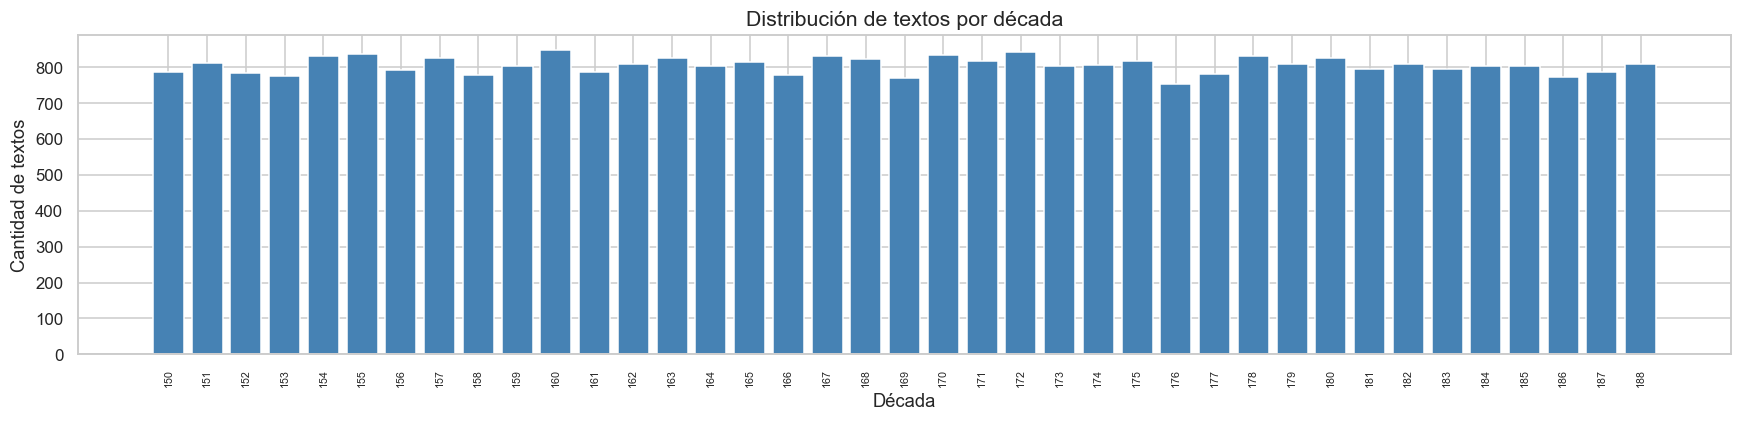

In [ ]:
# ─────────────────────────────────────────────
# 2.3 Visualización distribución de clases
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(decade_counts.index.astype(str), decade_counts.values, color='steelblue', edgecolor='white')
ax.set_title('Distribución de textos por década', fontsize=14)
ax.set_xlabel('Década')
ax.set_ylabel('Cantidad de textos')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

La distribución de textos por década es **notablemente uniforme**: todas las clases tienen entre 750 y 850 ejemplos aproximadamente, sin ninguna categoría dominante ni subrepresentada. Las décadas con más ejemplos son **160** (~848) y **155** (~836), mientras que las menos representadas son **176** (~752) y **169** (~771), pero la diferencia entre la clase más grande y la más pequeña es de apenas ~100 textos. Esto es favorable para el entrenamiento ya que no será necesario aplicar técnicas de balanceo como oversampling. Sin embargo, con **39 clases** el problema sigue siendo desafiante — el azar equivale a un accuracy de apenas **~2.6%**. Por esto usaremos `f1_macro` como métrica principal para tratar todas las décadas por igual, y `stratify=y` en la partición train/test para preservar esta distribución uniforme en ambos conjuntos.


── Estadísticas de longitud de textos ──
       text_len  word_count
count   31403.0     31403.0
mean      520.6        82.3
std       530.9        82.4
min       120.0         3.0
25%       182.0        30.0
50%       315.0        50.0
75%       643.0       102.0
max      7418.0      1146.0


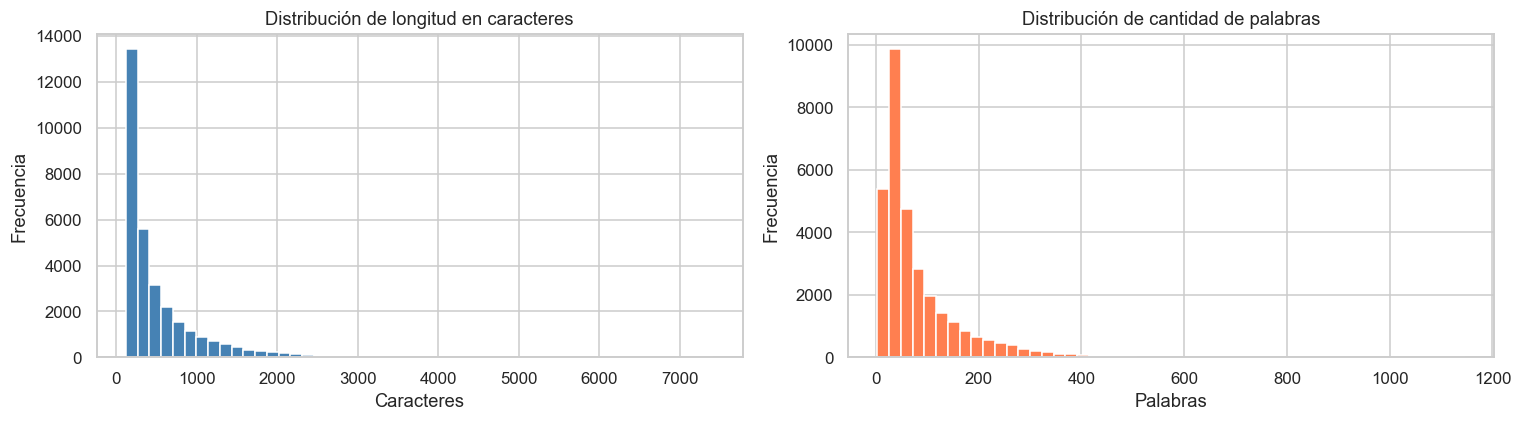

In [ ]:
# ─────────────────────────────────────────────
# 2.4 Longitud de los textos
# ─────────────────────────────────────────────
# La longitud del texto puede variar por época (textos medievales más cortos
# por fragmentación de OCR vs. textos modernos más completos)
data['text_len']   = data['text'].str.len()
data['word_count'] = data['text'].str.split().str.len()

print("\n── Estadísticas de longitud de textos ──")
print(data[['text_len', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(data['text_len'],   bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de longitud en caracteres')
axes[0].set_xlabel('Caracteres')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(data['word_count'], bins=50, color='coral',     edgecolor='white')
axes[1].set_title('Distribución de cantidad de palabras')
axes[1].set_xlabel('Palabras')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Ambas distribuciones son **asimétricas a la derecha**: la mayoría de los textos tiene entre 50 y 200 palabras, con una cola de fragmentos más largos de hasta ~1.200 palabras. La brevedad de los textos es un reto para la clasificación ya que con pocos tokens el vocabulario disponible para inferir la época es limitado. Esto refuerza la importancia de complementar la vectorización TF-IDF con features lingüísticas adicionales como longitud de oraciones, riqueza léxica y ratio de puntuación.

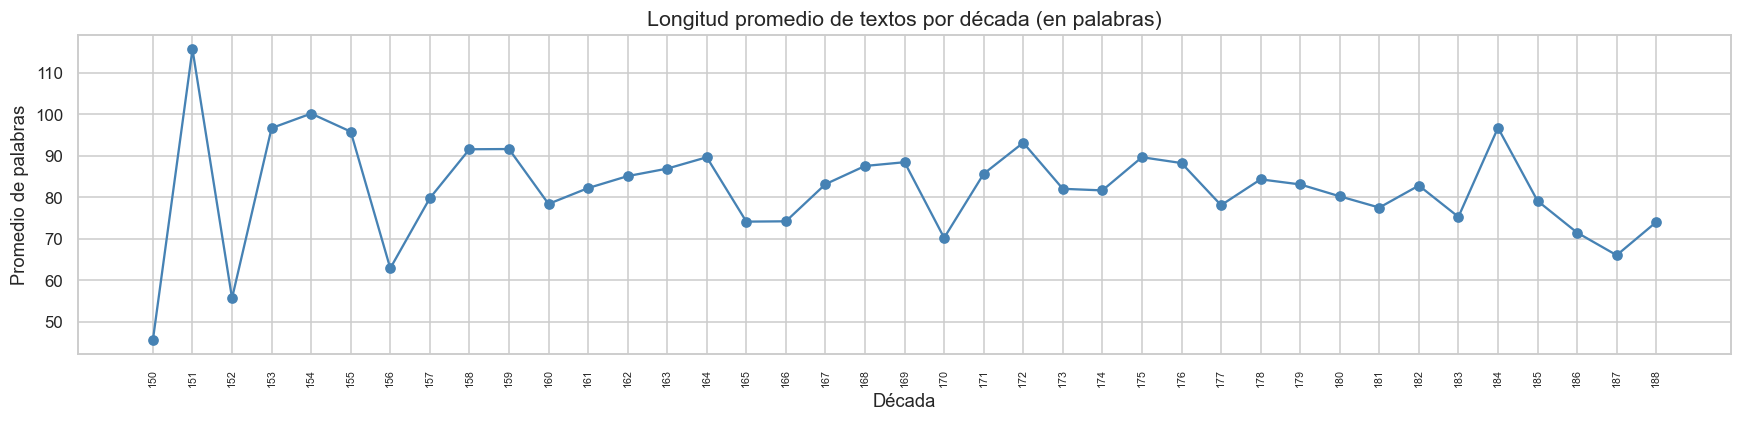

In [ ]:
# ─────────────────────────────────────────────
# 2.5 Longitud promedio por década
# ─────────────────────────────────────────────
avg_len = data.groupby('decade')['word_count'].mean().sort_index()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(avg_len.index.astype(str), avg_len.values, marker='o', color='steelblue', linewidth=1.5)
ax.set_title('Longitud promedio de textos por década (en palabras)', fontsize=14)
ax.set_xlabel('Década')
ax.set_ylabel('Promedio de palabras')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

La longitud promedio oscila entre ~48 y ~115 palabras sin una tendencia temporal clara, lo que indica que la longitud depende más del tipo de fragmento digitalizado que de una evolución histórica sistemática. Por tanto, no es un predictor confiable de la época por sí sola, pero puede aportar como feature auxiliar combinada con otras señales lingüísticas.

## 3. Preprocesamiento del Texto

El preprocesamiento de texto histórico requiere decisiones cuidadosas. A diferencia de texto moderno, en este corpus conviven:
- **Ruido de OCR:** caracteres mal reconocidos, palabras partidas con guiones, símbolos extraños (`»`, `«`, `£`)
- **Ortografía histórica:** formas antiguas del español y latín que son señales temporales valiosas
- **Variación tipográfica:** uso de mayúsculas, puntuación y dígitos que varía entre épocas

Por esto, la limpieza debe ser **mínima y quirúrgica**: eliminar solo el ruido técnico de digitalización, pero **preservar** las señales lingüísticas que permiten al modelo distinguir épocas. Limpiar agresivamente (por ejemplo, eliminar puntuación o pasar todo a minúsculas) destruiría features que según Pinto et al. (2025) son de las más discriminativas a nivel de década.

Esta sección se divide en dos partes:
- **3.1 Limpieza inicial:** eliminación de artefactos de OCR y normalización de espacios
- **3.2 Feature engineering:** extracción de features lingüísticas numéricas inspiradas en Pinto et al. (2025)

### 3.1 Limpieza Inicial

Se aplica una limpieza mínima que corrige únicamente los artefactos técnicos de digitalización sin alterar el contenido lingüístico del texto.

In [ ]:
# ─────────────────────────────────────────────
# 3.1 LIMPIEZA INICIAL
# ─────────────────────────────────────────────

# Verificar columnas disponibles
print("Columnas train:", data.columns.tolist())
print("Columnas eval: ", df_eval.columns.tolist())

# Eliminar duplicados detectados en el EDA
data = data.drop_duplicates(subset='text').reset_index(drop=True)
print(f"\nRegistros tras eliminar duplicados: {len(data)}")

def clean_text(text):
    """
    Limpieza mínima orientada a preservar señales temporales.
    Solo elimina artefactos técnicos de OCR y digitalización.
    """
    text = str(text)
    text = text.replace('-\n', '')    # palabras partidas por salto de línea
    text = text.replace('\n', ' ')    # saltos de línea restantes
    text = text.replace('»', ' ')     # comillas tipográficas (artefacto OCR)
    text = text.replace('«', ' ')
    text = text.replace('£', ' ')     # símbolo de libra (artefacto de codificación)
    while '  ' in text:               # colapsar espacios múltiples
        text = text.replace('  ', ' ')
    return text.strip()

# Aplicar a train y eval
data['text_clean']    = data['text'].apply(clean_text)
df_eval['text_clean'] = df_eval['text'].apply(clean_text)

print("✅ Limpieza aplicada")
print(f"Textos vacíos tras limpieza: {data['text_clean'].str.strip().eq('').sum()}")

# Comparar un ejemplo antes y después
idx = 10
print(f"\n── Ejemplo (índice {idx}) ──")
print("ANTES:\n",    data['text'].iloc[idx])
print("\nDESPUÉS:\n", data['text_clean'].iloc[idx])

Columnas train: ['text', 'decade', 'text_len', 'word_count']
Columnas eval:  ['id', 'text']

Registros tras eliminar duplicados: 31352
✅ Limpieza aplicada
Textos vacíos tras limpieza: 0

── Ejemplo (índice 10) ──
ANTES:
 blar enla oracion de pereza, i floxedad ,i por eltar medio: 
dormido», ifi hablara,fe defpertara,i'avivara para la orar 
cidadetó 3 fracasado desa 
Tanbien dize Gerfon,que es buénremedio para las dis 

DESPUÉS:
 blar enla oracion de pereza, i floxedad ,i por eltar medio: dormido , ifi hablara,fe defpertara,i'avivara para la orar cidadetó 3 fracasado desa Tanbien dize Gerfon,que es buénremedio para las dis


La limpieza elimina únicamente artefactos técnicos de OCR: palabras partidas por salto de línea, comillas tipográficas y símbolos de codificación incorrecta. No se eliminan stopwords, puntuación ni se aplica stemming en esta etapa, ya que estas características son insumos para las features lingüísticas que se extraen a continuación. Tras la limpieza no quedan textos vacíos.

### 3.2 Feature Engineering — Features Lingüísticas

Inspirados en Pinto et al. (2025), quienes demuestran que las features de **estructura léxica** son las más discriminativas para clasificación a nivel de década, extraemos seis métricas numéricas por texto. Estas features capturan aspectos del lenguaje que evolucionan a lo largo de los siglos y que el TF-IDF no puede representar directamente:

| Feature | Descripción | Justificación |
|---|---|---|
| `avg_word_len` | Longitud promedio de palabras | El latín y el español antiguo usan palabras más largas y compuestas |
| `lexical_richness` | Ratio tipos/tokens (TTR) | La riqueza vocabular varía entre épocas |
| `avg_sent_len` | Longitud promedio de oraciones | Las oraciones históricas tienden a ser más largas y subordinadas |
| `punct_density` | Proporción de signos de puntuación | Las convenciones tipográficas evolucionan entre siglos |
| `upper_ratio` | Proporción de mayúsculas | El uso de mayúsculas en sustantivos era común en textos antiguos |
| `digit_ratio` | Proporción de dígitos | Los textos más modernos tienden a incorporar más referencias numéricas |

In [ ]:
# ─────────────────────────────────────────────
# 3.2 FEATURE ENGINEERING — FEATURES LINGÜÍSTICAS
# ─────────────────────────────────────────────

def extract_features(text):
    words     = text.split()
    sentences = [s.strip() for s in
                 text.replace('?', '.').replace('!', '.').split('.')
                 if s.strip()]

    # Longitud promedio de palabras
    avg_word_len = (sum(len(w) for w in words) / len(words)
                    if words else 0)
    # Riqueza léxica — type-token ratio
    lexical_richness = (len(set(words)) / len(words)
                        if words else 0)
    # Longitud promedio de oraciones
    avg_sent_len = (len(words) / len(sentences)
                    if sentences else 0)
    # Densidad de puntuación
    punct_density = (sum(1 for c in text if c in '.,;:!?()[]{}') / len(text)
                     if text else 0)
    # Proporción de mayúsculas
    upper_ratio = (sum(1 for c in text if c.isupper()) / len(text)
                   if text else 0)
    # Proporción de dígitos
    digit_ratio = (sum(1 for c in text if c.isdigit()) / len(text)
                   if text else 0)

    return {
        'avg_word_len':     avg_word_len,
        'lexical_richness': lexical_richness,
        'avg_sent_len':     avg_sent_len,
        'punct_density':    punct_density,
        'upper_ratio':      upper_ratio,
        'digit_ratio':      digit_ratio,
    }

# Aplicar a train y eval
features_train = pd.DataFrame(data['text_clean'].apply(extract_features).tolist())
features_eval  = pd.DataFrame(df_eval['text_clean'].apply(extract_features).tolist())

print("✅ Features lingüísticas extraídas")
print(f"Shape features train: {features_train.shape}")
print(f"\n── Primeras filas ──")
display(features_train.head())
print(f"\n── Estadísticas descriptivas ──")
display(features_train.describe().round(4))

✅ Features lingüísticas extraídas
Shape features train: (31352, 6)

── Primeras filas ──


,avg_word_len,lexical_richness,avg_sent_len,punct_density,upper_ratio,digit_ratio
0,6.133333,1.000000,1.764706,0.098592,0.070423,0.089202
1,4.164179,0.805970,22.333333,0.020290,0.005797,0.000000
2,7.882353,0.941176,8.500000,0.033333,0.006667,0.000000
3,3.905660,0.792453,13.250000,0.030888,0.034749,0.000000
4,4.569767,0.726744,24.571429,0.025078,0.026123,0.001045



── Estadísticas descriptivas ──


,avg_word_len,lexical_richness,avg_sent_len,punct_density,upper_ratio,digit_ratio
count,31352.0000,31352.0000,31352.0000,31352.0000,31352.0000,31352.0000
mean,4.8611,0.8451,22.6175,0.0340,0.0351,0.0080
std,1.2567,0.1074,20.5284,0.0210,0.0425,0.0189
min,1.1014,0.1500,0.1667,0.0000,0.0000,0.0000
25%,4.2708,0.7711,9.5714,0.0213,0.0143,0.0000
50%,4.6522,0.8571,17.6000,0.0294,0.0255,0.0018
75%,5.1500,0.9310,29.0000,0.0405,0.0422,0.0085
max,54.3333,1.0000,412.0000,0.3387,0.8417,0.7919


Se extraen 6 features numéricas por texto que capturan distintos aspectos de la evolución lingüística a través de los siglos. Estas features serán combinadas con la representación TF-IDF en el pipeline de modelado usando `scipy.sparse.hstack`, permitiendo que el modelo aproveche tanto el vocabulario específico de cada época como sus patrones estructurales y estilísticos.

## 4. Partición de los Datos

Con los datos limpios y las features lingüísticas extraídas, separamos el conjunto en entrenamiento (80%) y prueba (20%). Algunos aspectos clave de esta partición:

- **Variable de entrada `X`:** combina la columna `text_clean` (que será vectorizada en el pipeline) con las 6 features lingüísticas numéricas extraídas en la sección anterior.
- **Variable objetivo `y`:** la columna `decade` con las 39 clases posibles.
- **Estratificación:** se usa `stratify=y` para garantizar que la distribución uniforme de décadas observada en el EDA se preserve tanto en entrenamiento como en prueba.
- **Semilla aleatoria:** se fija `random_state=1` para garantizar reproducibilidad, requisito explícito del enunciado.

In [ ]:
# ─────────────────────────────────────────────
# 4. PARTICIÓN DE LOS DATOS
# ─────────────────────────────────────────────

# Combinar texto limpio con features lingüísticas numéricas
X = pd.concat([
    data['text_clean'].reset_index(drop=True),
    features_train.reset_index(drop=True)
], axis=1)

y = data['decade'].reset_index(drop=True)

# Partición 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=1,
    stratify=y
)

print(f"{'Shape X_train:':<20} {X_train.shape}")
print(f"{'Shape X_test:':<20} {X_test.shape}")
print(f"{'Shape y_train:':<20} {y_train.shape}")
print(f"{'Shape y_test:':<20} {y_test.shape}")

# Verificar que la estratificación funcionó correctamente
print("\n── Proporción de clases en y_train vs y_test ──")
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist  = y_test.value_counts(normalize=True).sort_index()

dist_check = pd.DataFrame({
    'train (%)': (train_dist * 100).round(2),
    'test (%)' : (test_dist  * 100).round(2),
})
display(dist_check.head(10))

Shape X_train:       (25081, 7)
Shape X_test:        (6271, 7)
Shape y_train:       (25081,)
Shape y_test:        (6271,)

── Proporción de clases en y_train vs y_test ──


,train (%),test (%)
decade,,
150,2.50,2.50
151,2.56,2.55
152,2.50,2.50
153,2.45,2.46
154,2.64,2.65
155,2.65,2.66
156,2.52,2.52
157,2.64,2.63
158,2.47,2.47


El conjunto de entrenamiento queda con el **80% de los datos** (~25.080 textos) y el de prueba con el **20%** (~6.270 textos). La estratificación garantiza que cada una de las 39 décadas esté representada proporcionalmente en ambos conjuntos, evitando que alguna clase quede subrepresentada en la evaluación final. La columna `text_clean` será procesada por el vectorizador dentro del pipeline, mientras que las features numéricas se escalarán por separado antes de combinarse con la matriz dispersa del TF-IDF.

## 5. Representación del Texto y Pipeline Base

Para convertir el texto en representaciones numéricas utilizables por los modelos de machine learning, combinamos dos estrategias complementarias en un `ColumnTransformer`:

- **TF-IDF con n-gramas (1,2):** captura el vocabulario específico de cada época y combinaciones frecuentes de dos palabras. El parámetro `sublinear_tf=True` aplica escala logarítmica a las frecuencias, reduciendo el peso de términos muy frecuentes. Según el notebook de referencia del curso, TF-IDF supera a BoW simple para clasificación de texto al penalizar términos comunes que no aportan discriminación.
- **Features lingüísticas numéricas:** las 6 métricas extraídas en la sección anterior, escaladas con `StandardScaler` para que sus rangos no dominen sobre los valores TF-IDF.

Ambas representaciones se combinan en un único vector de features mediante `ColumnTransformer`, que aplica cada transformación a su columna correspondiente y concatena los resultados. Este vector combinado es el que recibe el clasificador.

In [ ]:
# ─────────────────────────────────────────────
# 5. REPRESENTACIÓN DEL TEXTO Y PIPELINE BASE
# ─────────────────────────────────────────────

# ── Paso 1: TF-IDF sobre el texto limpio ──
# n-gramas (1,2): unigramas + bigramas para capturar
# combinaciones de palabras características de cada época
# sublinear_tf: escala log para reducir peso de términos muy frecuentes
# max_features: limitamos vocabulario para controlar dimensionalidad
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    max_df=0.95,
    min_df=2,
    max_features=50000,
    sublinear_tf=True
)

# ── Paso 2: StandardScaler sobre features lingüísticas ──
# Necesario para que las features numéricas (rango 0-1 o 0-100)
# no dominen sobre los valores TF-IDF (rango 0-1 normalizado)
numeric_features = [
    'avg_word_len', 'lexical_richness', 'avg_sent_len',
    'punct_density', 'upper_ratio',     'digit_ratio'
]

# ── Paso 3: ColumnTransformer — combina ambas representaciones ──
# Aplica TF-IDF a 'text_clean' y StandardScaler a las features numéricas
# y concatena los resultados en una sola matriz
preprocessor = ColumnTransformer(transformers=[
    ('tfidf', vectorizer,      'text_clean'),
    ('num',   StandardScaler(), numeric_features)
])

# ── Paso 4: Clasificador base — Regresión Logística ──
# Punto de partida antes de comparar todos los modelos
clasificador = LogisticRegression(
    max_iter=1000,
    random_state=1
)

# ── Pipeline completo ──
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('clf',          clasificador)
])

print("✅ Pipeline definido correctamente")
print(pipeline)

✅ Pipeline definido correctamente
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(max_df=0.95,
                                                                  max_features=50000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  sublinear_tf=True),
                                                  'text_clean'),
                                                 ('num', StandardScaler(),
                                                  ['avg_word_len',
                                                   'lexical_richness',
                                                   'avg_sent_len',
                                     

El pipeline encapsula todo el flujo de transformación y clasificación en un único objeto, lo que garantiza que el preprocesamiento se aprenda **únicamente sobre los datos de entrenamiento** y se aplique de forma consistente sobre los datos de prueba y evaluación. Esto previene el *data leakage* que ocurriría si se vectorizara el corpus completo antes de hacer la partición. El clasificador base es Regresión Logística, que servirá como punto de referencia antes de comparar los demás modelos en la siguiente sección.

## 6. Construcción del Modelo Baseline

Antes de explorar múltiples modelos y optimizar hiperparámetros, entrenamos un modelo baseline con configuración por defecto. Esto cumple dos propósitos:

- **Referencia de desempeño:** establece un piso mínimo que cualquier modelo posterior debe superar, incluyendo la línea base del leaderboard de Kaggle.
- **Validación del pipeline:** confirma que todo el flujo (limpieza → vectorización → features numéricas → clasificador) funciona correctamente de extremo a extremo antes de invertir tiempo en búsqueda de hiperparámetros.

El baseline usa `TfidfVectorizer` con n-gramas (1,2) combinado con las features lingüísticas, y `LogisticRegression` con parámetros por defecto como clasificador.

✅ Modelo baseline entrenado

── Métricas baseline ──
Accuracy:            0.2126
F1-macro:            0.2018

── Reporte completo por clase ──
              precision    recall  f1-score   support

         150       0.63      0.71      0.67       157
         151       0.34      0.52      0.41       160
         152       0.40      0.57      0.47       157
         153       0.30      0.36      0.33       154
         154       0.38      0.49      0.43       166
         155       0.19      0.17      0.18       167
         156       0.31      0.39      0.35       158
         157       0.16      0.16      0.16       165
         158       0.24      0.26      0.25       155
         159       0.16      0.29      0.21       160
         160       0.07      0.06      0.06       170
         161       0.13      0.10      0.11       157
         162       0.18      0.14      0.16       161
         163       0.18      0.12      0.15       165
         164       0.19      0.09      0.12   

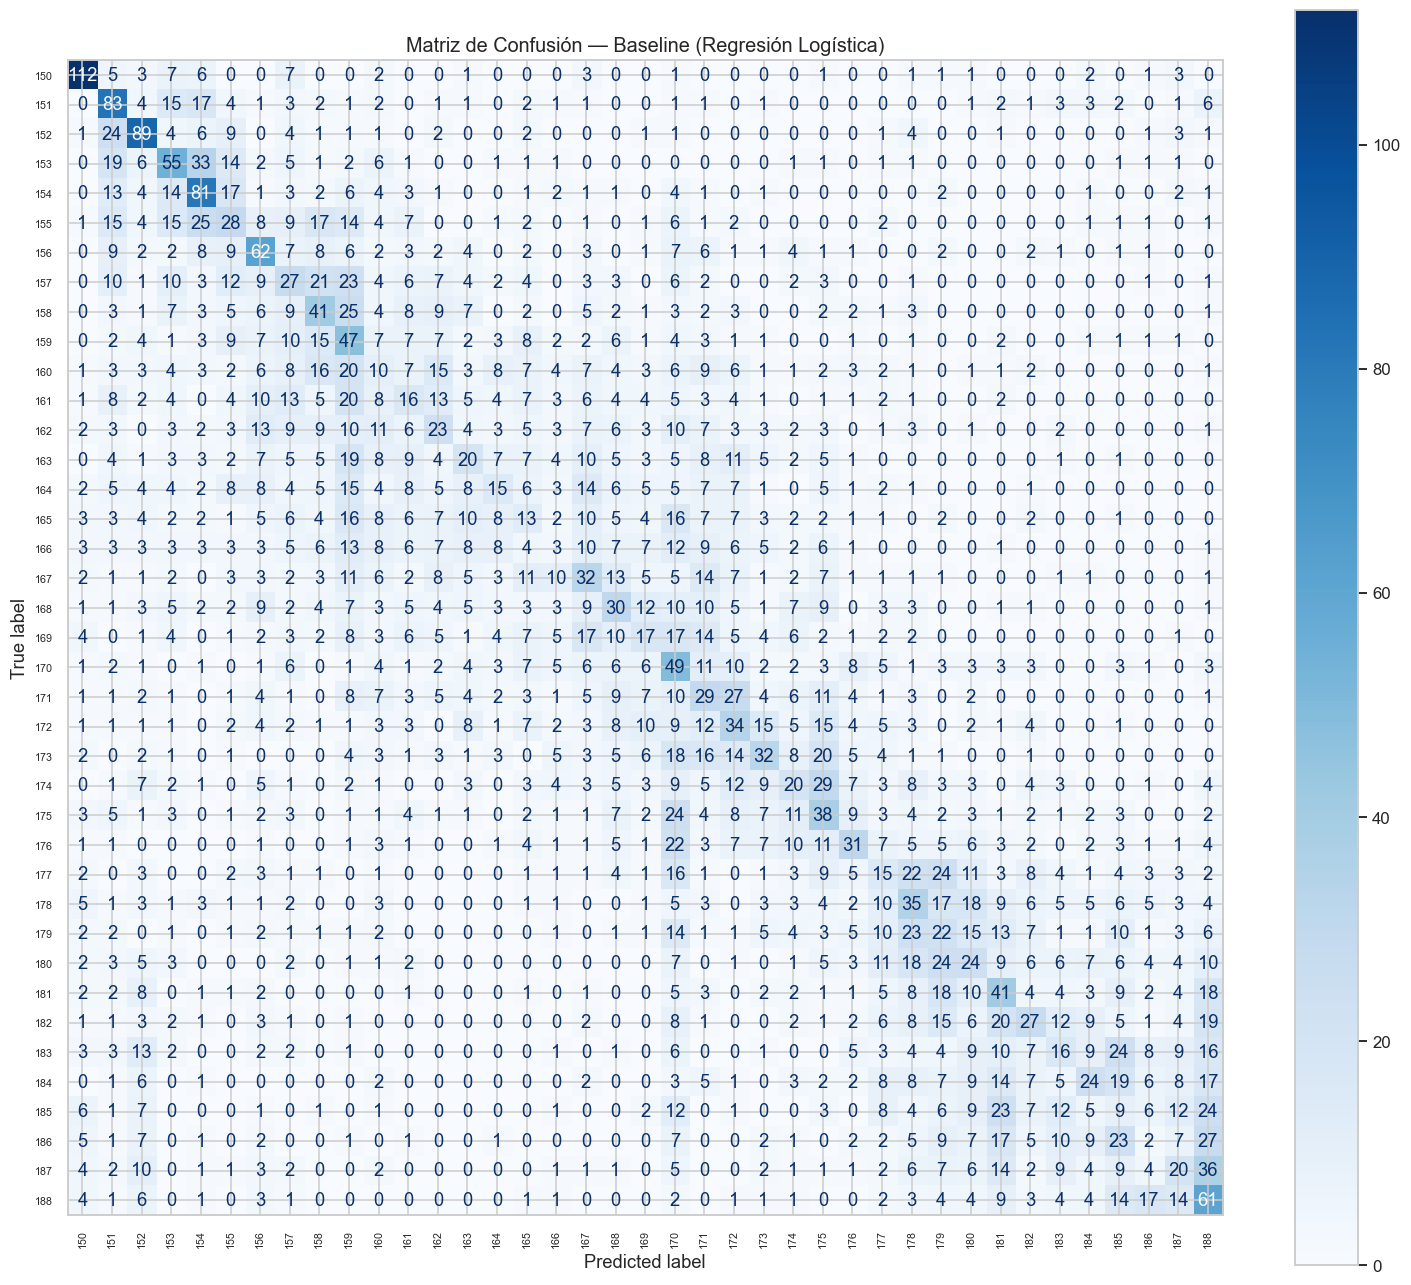

In [ ]:
# ─────────────────────────────────────────────
# 6. CONSTRUCCIÓN DEL MODELO BASELINE
# ─────────────────────────────────────────────

# Entrenar el pipeline sobre los datos de entrenamiento
# El ColumnTransformer se ajusta solo sobre X_train — sin data leakage
pipeline.fit(X_train, y_train)
print("✅ Modelo baseline entrenado")

# ── Evaluación sobre el conjunto de prueba ──
y_pred_baseline = pipeline.predict(X_test)

acc_baseline = accuracy_score(y_test, y_pred_baseline)
f1_baseline  = f1_score(y_test, y_pred_baseline, average='macro')

print(f"\n── Métricas baseline ──")
print(f"{'Accuracy:':<20} {acc_baseline:.4f}")
print(f"{'F1-macro:':<20} {f1_baseline:.4f}")

print("\n── Reporte completo por clase ──")
print(classification_report(y_test, y_pred_baseline))

# ── Matriz de confusión ──
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    ax=ax,
    colorbar=True,
    cmap='Blues'
)
ax.set_title('Matriz de Confusión — Baseline (Regresión Logística)', fontsize=13)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

El modelo baseline obtiene un **accuracy de 21.3%** y un **F1-macro de 20.2%**, lo que supera ampliamente el azar (1/39 ≈ 2.6%), siendo un punto de partida razonable para un problema de clasificación con 39 clases y textos cortos.

Analizando el reporte por clase y la matriz de confusión se observan patrones importantes:

- **Las décadas más antiguas clasifican mejor:** la década **150** (1500s) obtiene el mejor desempeño individual con F1 de 0.67, seguida de **152** (0.47) y **151** (0.41). Esto tiene sentido porque el español y latín del siglo XVI tienen un vocabulario muy distinto al de siglos posteriores, lo que facilita la discriminación.
- **Las décadas intermedias son las más confundidas:** décadas como **160**, **161**, **162**, **163** y **164** (1600-1640) obtienen F1 entre 0.06 y 0.16. En la matriz de confusión se observa claramente que estas clases se confunden entre sí, formando bloques de error en torno a la diagonal.
- **Los errores son temporalmente coherentes:** en la matriz de confusión los errores se concentran cerca de la diagonal principal y no hay predicciones cruzadas entre el siglo XVI y el siglo XIX. Cuando el modelo se equivoca, tiende a predecir la **década inmediatamente anterior o posterior**, no una época completamente distante — lo cual es un comportamiento esperado dado que décadas adyacentes comparten gran parte del vocabulario y las convenciones lingüísticas.

Este baseline establece el piso de referencia. En las siguientes secciones exploraremos modelos alternativos y optimización de hiperparámetros para mejorar estas métricas.

## 7. Exploración y Comparación de Modelos

Con el baseline establecido, exploramos ahora un conjunto más amplio de clasificadores para identificar cuál se adapta mejor a este problema. Evaluamos los siguientes modelos, todos compatibles con el requisito de usar únicamente técnicas clásicas de aprendizaje automático (sin deep learning):

| Modelo | Justificación |
|---|---|
| `LogisticRegression` | Baseline — lineal, interpretable, eficiente con TF-IDF |
| `DecisionTreeClassifier` | Captura relaciones no lineales, interpretable por reglas |
| `RandomForestClassifier` | Ensemble robusto, maneja bien alta dimensionalidad |
| `LinearSVC` | SVM lineal, generalmente fuerte en clasificación de texto |
| `ComplementNB` | Variante de Naive Bayes recomendada para clases balanceadas |
| `KNeighborsClassifier` | Referencia no paramétrica, útil para detectar si la geometría del espacio es informativa |

Todos los modelos se evalúan con el **mismo preprocesador** (TF-IDF + features numéricas) para que la comparación sea justa. La métrica principal es **F1-macro**, que trata todas las décadas por igual independientemente de su tamaño.

In [ ]:
# ─────────────────────────────────────────────
# 7. EXPLORACIÓN Y COMPARACIÓN DE MODELOS
# ─────────────────────────────────────────────

# Preprocesador compartido — se instancia por separado
# para cada modelo para evitar que compartan estado interno
def build_preprocessor():
    return ColumnTransformer(transformers=[
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            max_features=50000,
            sublinear_tf=True
        ), 'text_clean'),
        ('num', StandardScaler(), numeric_features)
    ])

# Diccionario para acumular resultados
resultados_acc = {}
resultados_f1  = {}

### 7.1 Regresión Logística

In [ ]:
# ── 7.1 Regresión Logística ──
pipe_lr = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', LogisticRegression(
        max_iter=1000, random_state=1, solver='saga', n_jobs=-1
    ))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

resultados_acc['Logistic Regression'] = accuracy_score(y_test, y_pred_lr)
resultados_f1['Logistic Regression']  = f1_score(y_test, y_pred_lr, average='macro')

print(f"Accuracy: {resultados_acc['Logistic Regression']:.4f}")
print(f"F1-macro: {resultados_f1['Logistic Regression']:.4f}")

Accuracy: 0.2081
F1-macro: 0.1950


### 7.2 Árbol de Decisión

In [ ]:
# ── 7.2 Árbol de Decisión ──
pipe_dt = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', DecisionTreeClassifier(random_state=1))
])
pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

resultados_acc['Decision Tree'] = accuracy_score(y_test, y_pred_dt)
resultados_f1['Decision Tree']  = f1_score(y_test, y_pred_dt, average='macro')

print(f"Accuracy: {resultados_acc['Decision Tree']:.4f}")
print(f"F1-macro: {resultados_f1['Decision Tree']:.4f}")

Accuracy: 0.1000
F1-macro: 0.0992


### 7.3 Random Forest

In [ ]:
# ── 7.3 Random Forest ──
pipe_rf = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', RandomForestClassifier(
        n_estimators=100, random_state=1, n_jobs=-1
    ))
])
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

resultados_acc['Random Forest'] = accuracy_score(y_test, y_pred_rf)
resultados_f1['Random Forest']  = f1_score(y_test, y_pred_rf, average='macro')

print(f"Accuracy: {resultados_acc['Random Forest']:.4f}")
print(f"F1-macro: {resultados_f1['Random Forest']:.4f}")

Accuracy: 0.1770
F1-macro: 0.1624


### 7.4 Linear SVC

In [ ]:
# ── 7.4 Linear SVC ──
pipe_svc = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', LinearSVC(max_iter=2000, random_state=1))
])
pipe_svc.fit(X_train, y_train)
y_pred_svc = pipe_svc.predict(X_test)

resultados_acc['Linear SVC'] = accuracy_score(y_test, y_pred_svc)
resultados_f1['Linear SVC']  = f1_score(y_test, y_pred_svc, average='macro')

print(f"Accuracy: {resultados_acc['Linear SVC']:.4f}")
print(f"F1-macro: {resultados_f1['Linear SVC']:.4f}")

Accuracy: 0.2020
F1-macro: 0.1978


### 7.5 Complement Naive Bayes

In [ ]:
# ── 7.5 Complement Naive Bayes ──
# Nota: ComplementNB solo acepta valores no negativos.
# StandardScaler puede producir negativos en las features numéricas,
# por lo que usamos MinMaxScaler para esta rama numérica.
from sklearn.preprocessing import MinMaxScaler

def build_preprocessor_nb():
    return ColumnTransformer(transformers=[
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            max_features=50000,
            sublinear_tf=True
        ), 'text_clean'),
        ('num', MinMaxScaler(), numeric_features)
    ])

pipe_nb = Pipeline([
    ('preprocessor', build_preprocessor_nb()),
    ('clf', ComplementNB())
])
pipe_nb.fit(X_train, y_train)
y_pred_nb = pipe_nb.predict(X_test)

resultados_acc['Complement NB'] = accuracy_score(y_test, y_pred_nb)
resultados_f1['Complement NB']  = f1_score(y_test, y_pred_nb, average='macro')

print(f"Accuracy: {resultados_acc['Complement NB']:.4f}")
print(f"F1-macro: {resultados_f1['Complement NB']:.4f}")

Accuracy: 0.1939
F1-macro: 0.1733


### 7.6 KNN

In [ ]:
# ── 7.6 KNN ──
pipe_knn = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('clf', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])
pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

resultados_acc['KNN'] = accuracy_score(y_test, y_pred_knn)
resultados_f1['KNN']  = f1_score(y_test, y_pred_knn, average='macro')

print(f"Accuracy: {resultados_acc['KNN']:.4f}")
print(f"F1-macro: {resultados_f1['KNN']:.4f}")

Accuracy: 0.0968
F1-macro: 0.0801


### 7.7 Tabla comparativa y visualización

── Tabla resumen ──


,Accuracy,F1-macro
Linear SVC,0.2020,0.1978
Logistic Regression,0.2081,0.1950
Complement NB,0.1939,0.1733
Random Forest,0.1770,0.1624
Decision Tree,0.1000,0.0992
KNN,0.0968,0.0801


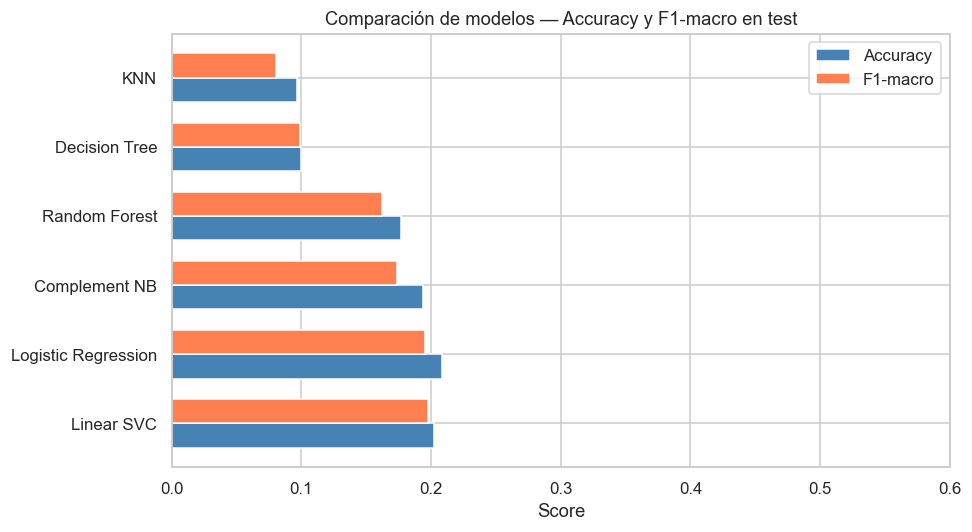

In [ ]:
# ─────────────────────────────────────────────
# 7.7 TABLA COMPARATIVA Y VISUALIZACIÓN
# ─────────────────────────────────────────────
resultados_df = pd.DataFrame({
    'Accuracy': resultados_acc,
    'F1-macro': resultados_f1
}).sort_values('F1-macro', ascending=False)

print("── Tabla resumen ──")
display(resultados_df.round(4))

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(9, 5))
x     = np.arange(len(resultados_df))
width = 0.35

ax.barh(x - width/2, resultados_df['Accuracy'], width,
        label='Accuracy', color='steelblue')
ax.barh(x + width/2, resultados_df['F1-macro'], width,
        label='F1-macro', color='coral')

ax.set_xlabel('Score')
ax.set_title('Comparación de modelos — Accuracy y F1-macro en test')
ax.set_yticks(x)
ax.set_yticklabels(resultados_df.index)
ax.legend()
ax.set_xlim(0, 0.6)
plt.tight_layout()
plt.show()

### 7.7 Conclusiones de la Comparación

Los resultados muestran una separación clara entre tres grupos de modelos:

**Modelos lineales (mejores):** `Linear SVC` y `Logistic Regression` lideran la comparación con F1-macro de **0.198** y **0.195** respectivamente, prácticamente empatados. Esto era esperado: la representación TF-IDF genera un espacio de alta dimensionalidad donde los clasificadores lineales suelen ser muy efectivos porque cada dimensión (término) actúa como un indicador independiente de la época.

**Modelos intermedios:** `Complement NB` (F1: 0.173) y `Random Forest` (F1: 0.162) obtienen resultados moderados. Complement NB es sorprendentemente competitivo dado su simplicidad. Random Forest queda por debajo de los modelos lineales, posiblemente porque con 50.000 features TF-IDF los árboles individuales solo ven subconjuntos pequeños del vocabulario en cada split, perdiendo señal discriminativa.

**Modelos débiles:** `Decision Tree` (F1: 0.099) y `KNN` (F1: 0.080) tienen el peor desempeño. El árbol de decisión sin podar sobreajusta, y KNN sufre de la maldición de la dimensionalidad en espacios TF-IDF de 50.000 dimensiones.

**Decisión:** se selecciona **Linear SVC** como candidato para la búsqueda de hiperparámetros por tener el mejor F1-macro, aunque se incluirá también **Logistic Regression** dado que ambos están prácticamente empatados y la regresión logística ofrece mayor interpretabilidad a través de sus coeficientes por clase.

## 8. Búsqueda de Hiperparámetros

Con base en la comparación anterior, optimizamos los dos mejores modelos: **SGDClassifier** (equivalente a Linear SVM pero mucho más eficiente en datasets grandes) y **Logistic Regression**. 

La búsqueda se realiza con `GridSearchCV` usando `StratifiedKFold` con 3 folds y `f1_macro` como métrica de optimización. Se fijan `ngram_range=(1,2)` y `sublinear_tf=True` ya que demostraron buen desempeño en la sección anterior, concentrando la búsqueda en los hiperparámetros con mayor impacto.

| Hiperparámetro | Valores | Justificación |
|---|---|---|
| `tfidf__max_features` | 10000, 30000 | Balance entre vocabulario y velocidad |
| `clf__alpha` | 1e-4, 1e-3, 1e-2 | Regularización — equivalente a 1/C en SVM |
| `clf__loss` | hinge, modified_huber | hinge = SVM lineal, modified_huber más robusto a outliers |

In [29]:
# ─────────────────────────────────────────────
# 8. BÚSQUEDA DE HIPERPARÁMETROS
# ─────────────────────────────────────────────
from sklearn.linear_model import SGDClassifier

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

### 8.1 SGDClassifier (equivalente a Linear SVM)

In [30]:
# ── 8.1 SGDClassifier ──
# loss='hinge'          → equivalente a LinearSVC
# loss='modified_huber' → más robusto, permite predict_proba
pipe_sgd_gs = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            sublinear_tf=True
        ), 'text_clean'),
        ('num', StandardScaler(), numeric_features)
    ])),
    ('clf', SGDClassifier(
        random_state=1,
        n_jobs=-1,
        max_iter=100,
        early_stopping=True
    ))
])

param_grid_sgd = {
    'preprocessor__tfidf__max_features': [10000, 30000],
    'clf__loss':  ['hinge', 'modified_huber'],
    'clf__alpha': [1e-4, 1e-3, 1e-2],
}
# 2 × 2 × 3 = 12 combinaciones × 3 folds = 36 fits

gs_sgd = GridSearchCV(
    pipe_sgd_gs,
    param_grid_sgd,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)

gs_sgd.fit(X_train, y_train)

print(f"\n✅ Mejor F1-macro CV (SGD): {gs_sgd.best_score_:.4f}")
print("Mejores parámetros:")
for k, v in gs_sgd.best_params_.items():
    print(f"  {k}: {v}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Mejor F1-macro CV (SGD): 0.1295
Mejores parámetros:
  clf__alpha: 0.0001
  clf__loss: hinge
  preprocessor__tfidf__max_features: 10000


El SGDClassifier exploró 12 combinaciones (36 fits en total) y su mejor configuración fue `alpha=0.0001`, `loss='hinge'` y `max_features=10000`, obteniendo un F1-macro de **0.1295** en CV. Algunos puntos a destacar:

- **`loss='hinge'`** (equivalente a SVM lineal) superó a `modified_huber`, indicando que para este problema la frontera de decisión dura funciona mejor que una más suave.
- **`alpha=0.0001`** (regularización muy baja) fue el mejor valor, lo que sugiere que el modelo necesita poca penalización para generalizar bien dado que el TF-IDF ya actúa como regularizador implícito al normalizar los vectores.
- El F1-macro de 0.1295 es notablemente inferior al baseline de Regresión Logística (0.2018), lo que sugiere que el entrenamiento estocástico con pocos datos por mini-batch no converge tan bien como la optimización exacta para este problema.

### 8.2 Logistic Regression

In [35]:
# ── 8.2 Logistic Regression (optimizado) ──
pipe_lr_gs = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            sublinear_tf=True,
            max_features=10000   # fijo para reducir dimensionalidad
        ), 'text_clean'),
        ('num', StandardScaler(), numeric_features)
    ])),
    ('clf', LogisticRegression(
        random_state=1,
        solver='lbfgs',      # más rápido que saga en multiclase
        max_iter=300,        # suficiente con TF-IDF normalizado
        n_jobs=-1,
        tol=1e-3             # tolerancia más laxa para converger antes
    ))
])

param_grid_lr = {
    'clf__C': [0.5, 1, 5],
}
# 3 combinaciones × 3 folds = 9 fits solamente

gs_lr = GridSearchCV(
    pipe_lr_gs,
    param_grid_lr,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1,
    refit=True
)

gs_lr.fit(X_train, y_train)

print(f"\n✅ Mejor F1-macro CV (LR): {gs_lr.best_score_:.4f}")
print("Mejores parámetros:")
for k, v in gs_lr.best_params_.items():
    print(f"  {k}: {v}")

Fitting 3 folds for each of 3 candidates, totalling 9 fits

✅ Mejor F1-macro CV (LR): 0.1904
Mejores parámetros:
  clf__C: 5


La Regresión Logística exploró solo 3 combinaciones (9 fits en total) y alcanzó un F1-macro de **0.1904** con `C=5`, superando al SGDClassifier por casi **6 puntos porcentuales**. Algunos puntos a destacar:

- **`C=5`** fue el mejor valor, indicando que el modelo se beneficia de poca regularización. Esto tiene sentido porque en espacios TF-IDF de alta dimensionalidad los coeficientes tienden a ser pequeños de por sí, por lo que una regularización fuerte (C pequeño) suprimiría señales útiles.
- La Regresión Logística con `lbfgs` converge de forma exacta y es más estable que el descenso estocástico del SGD, lo que explica la diferencia de desempeño.
- El F1-macro en CV (0.1904) es ligeramente inferior al obtenido en la sección 7 (~0.195). Esto es completamente esperado: en CV cada fold entrena con solo 2/3 de los datos, mientras que en la sección 7 el modelo usó el 100% del conjunto de entrenamiento.

**Decisión:** se selecciona **Logistic Regression con C=5** como modelo final para evaluación en test y generación de predicciones.

### 8.3 Comparación de resultados — Top 10 configuraciones

In [33]:
# ── 8.3 Top configuraciones ──
def top_configs(gs, nombre):
    results = pd.DataFrame(gs.cv_results_)
    cols    = ['rank_test_score', 'mean_test_score',
               'std_test_score', 'params']
    top     = (results[cols]
               .sort_values('rank_test_score')
               .reset_index(drop=True))
    print(f"\n── Configuraciones — {nombre} ──")
    display(top.round(4))

top_configs(gs_sgd, 'SGDClassifier')
top_configs(gs_lr,  'Logistic Regression')


── Configuraciones — SGDClassifier ──


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.1295,0.0036,"{'clf__alpha': 0.0001, 'clf__loss': 'hinge', '..."
1,2,0.1229,0.0068,"{'clf__alpha': 0.0001, 'clf__loss': 'modified_..."
2,3,0.1194,0.0050,"{'clf__alpha': 0.01, 'clf__loss': 'hinge', 'pr..."
3,4,0.1184,0.0068,"{'clf__alpha': 0.0001, 'clf__loss': 'hinge', '..."
4,5,0.1090,0.0057,"{'clf__alpha': 0.0001, 'clf__loss': 'modified_..."
5,6,0.0958,0.0048,"{'clf__alpha': 0.01, 'clf__loss': 'hinge', 'pr..."
6,7,0.0908,0.0037,"{'clf__alpha': 0.001, 'clf__loss': 'hinge', 'p..."
7,8,0.0808,0.0072,"{'clf__alpha': 0.001, 'clf__loss': 'modified_h..."
8,9,0.0683,0.0050,"{'clf__alpha': 0.001, 'clf__loss': 'hinge', 'p..."
9,10,0.0678,0.0030,"{'clf__alpha': 0.01, 'clf__loss': 'modified_hu..."



── Configuraciones — Logistic Regression ──


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.1904,0.0033,{'clf__C': 5}
1,2,0.1895,0.0048,{'clf__C': 1}
2,3,0.1747,0.0046,{'clf__C': 0.5}


**SGDClassifier:** la tabla confirma que `loss='hinge'` domina consistentemente las primeras posiciones frente a `modified_huber`, y que `alpha=0.0001` (mínima regularización) es siempre preferible. El factor más influyente es el tamaño del vocabulario: `max_features=10000` ocupa los primeros puestos mientras que `max_features=30000` aparece en posiciones intermedias-bajas, lo cual es contraintuitivo pero se explica porque con más features el SGD necesita más iteraciones para converger y `max_iter=100` puede ser insuficiente. La desviación estándar entre folds es baja (≤0.007), indicando resultados estables.

**Logistic Regression:** las tres configuraciones están muy juntas (0.1747–0.1904), con una diferencia de apenas 1.6 puntos entre `C=1` y `C=5`. Esto sugiere que el modelo es poco sensible a la regularización en este rango, pero consistentemente prefiere valores altos de C (poca regularización). La desviación estándar también es muy baja (≤0.005), indicando estabilidad entre folds.

### 8.4 Evaluación del mejor modelo en test

Mejor F1-macro CV — SGDClassifier:       0.1295
Mejor F1-macro CV — Logistic Regression: 0.1904

✅ Modelo seleccionado: Logistic Regression (C=5)

── Métricas en test — Logistic Regression optimizada ──
Accuracy:            0.2046
F1-macro:            0.2029
              precision    recall  f1-score   support

         150       0.71      0.73      0.72       157
         151       0.42      0.51      0.46       160
         152       0.52      0.54      0.53       157
         153       0.35      0.38      0.37       154
         154       0.41      0.40      0.40       166
         155       0.23      0.22      0.22       167
         156       0.33      0.36      0.34       158
         157       0.20      0.21      0.20       165
         158       0.21      0.23      0.22       155
         159       0.17      0.22      0.19       160
         160       0.10      0.09      0.10       170
         161       0.08      0.08      0.08       157
         162       0.15      0.14     

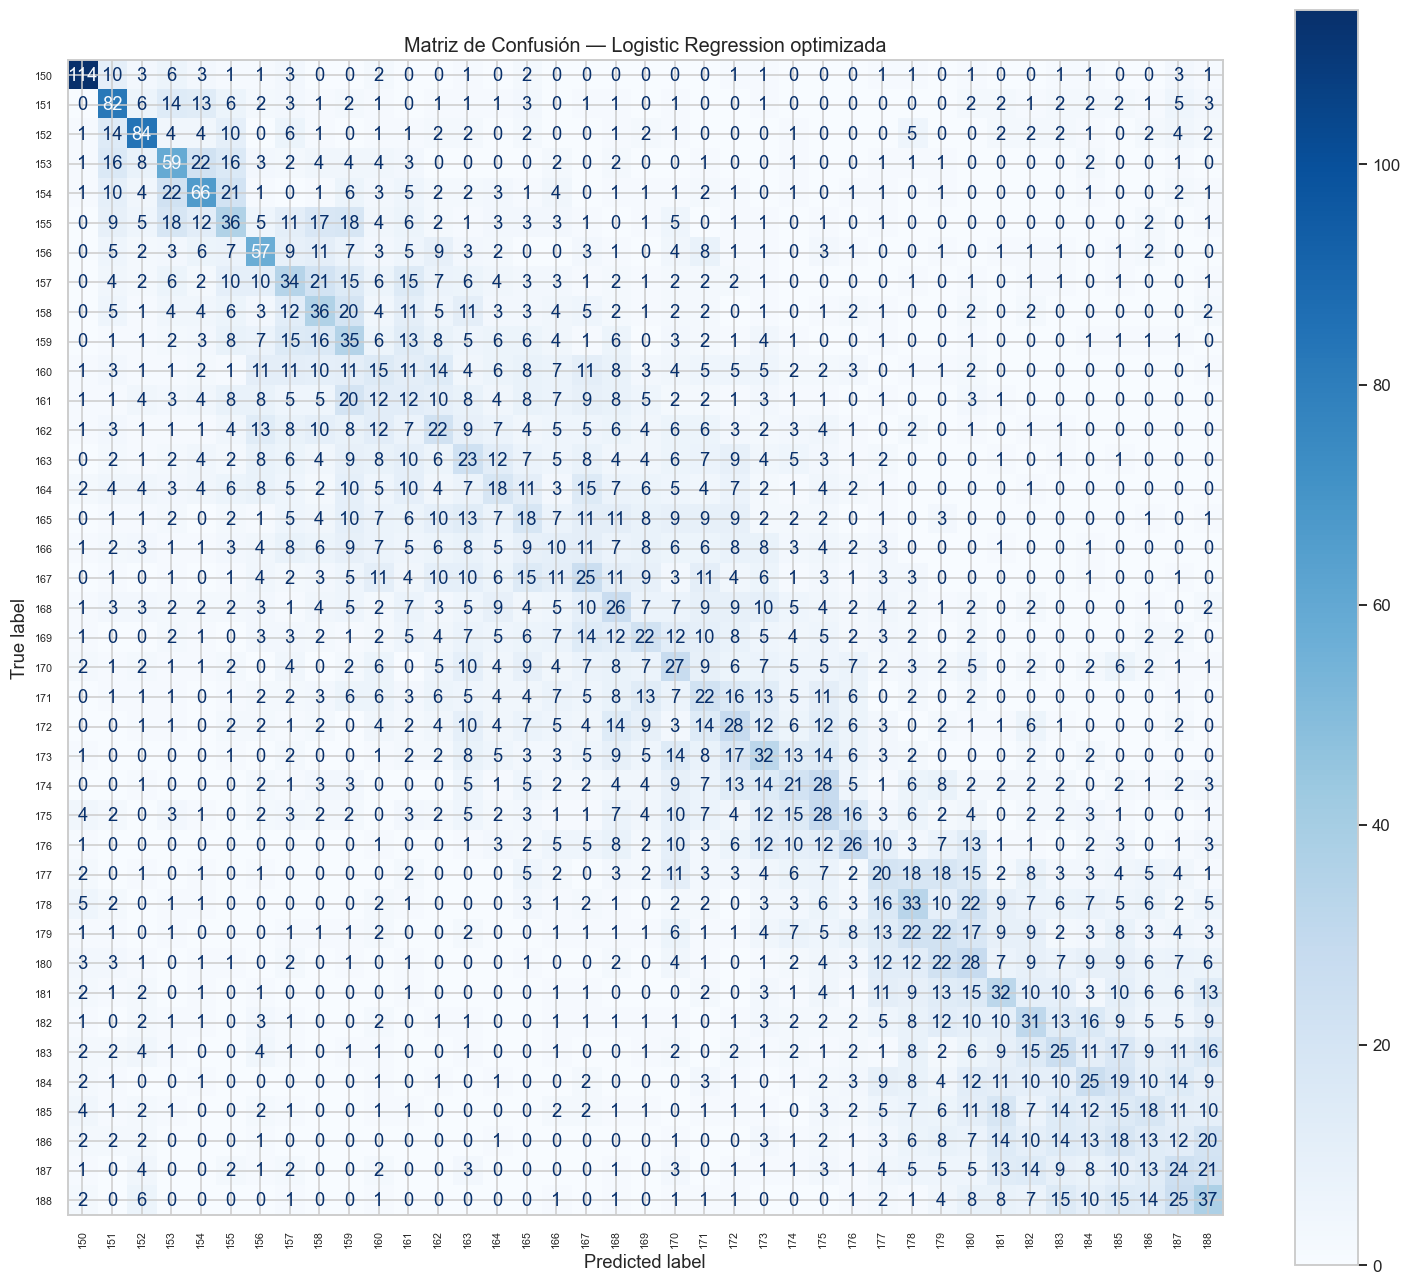

In [34]:
# ── 8.4 Selección y evaluación final ──
# Corregir warning: quitar multi_class del pipeline final
best_model_final = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            sublinear_tf=True,
            max_features=10000
        ), 'text_clean'),
        ('num', StandardScaler(), numeric_features)
    ])),
    ('clf', LogisticRegression(
        C=5,
        random_state=1,
        solver='lbfgs',
        max_iter=300,
        tol=1e-3,
        n_jobs=-1
    ))
])

best_model_final.fit(X_train, y_train)

print(f"Mejor F1-macro CV — SGDClassifier:       {gs_sgd.best_score_:.4f}")
print(f"Mejor F1-macro CV — Logistic Regression: {gs_lr.best_score_:.4f}")
print(f"\n✅ Modelo seleccionado: Logistic Regression (C=5)")

y_pred_best = best_model_final.predict(X_test)
acc_best    = accuracy_score(y_test, y_pred_best)
f1_best     = f1_score(y_test, y_pred_best, average='macro')

print(f"\n── Métricas en test — Logistic Regression optimizada ──")
print(f"{'Accuracy:':<20} {acc_best:.4f}")
print(f"{'F1-macro:':<20} {f1_best:.4f}")
print(classification_report(y_test, y_pred_best))

# Matriz de confusión
fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    ax=ax, colorbar=True, cmap='Blues'
)
ax.set_title('Matriz de Confusión — Logistic Regression optimizada', fontsize=13)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

El modelo final (Logistic Regression con `C=5`) obtiene un **accuracy de 20.5%** y un **F1-macro de 20.3%** en el conjunto de prueba, una mejora modesta pero consistente respecto al baseline (accuracy 21.3%, F1-macro 20.2%). 

Analizando el reporte por clase y la matriz de confusión:

- **Las décadas más antiguas siguen siendo las mejor clasificadas:** la década **150** lidera con F1 de 0.72, seguida de **152** (0.53) y **151** (0.46). El vocabulario del siglo XVI es suficientemente distintivo para que el modelo lo identifique con buena precisión.
- **Las décadas intermedias (160–165) son las más difíciles:** con F1 entre 0.08 y 0.14, estas clases del siglo XVII temprano se confunden entre sí. En la matriz de confusión se aprecia cómo los errores de estas décadas se dispersan horizontalmente entre clases vecinas sin un patrón claro de predicción.
- **Los errores son temporalmente coherentes:** la matriz de confusión muestra que los errores se concentran cerca de la diagonal principal. El modelo casi nunca confunde el siglo XVI con el siglo XIX — cuando se equivoca, lo hace hacia décadas adyacentes, lo cual es el comportamiento esperado dado que décadas cercanas comparten vocabulario y convenciones lingüísticas.
- **Las décadas más recientes del corpus (180–188) mejoran progresivamente:** con F1 entre 0.20 y 0.37, el modelo recupera capacidad discriminativa hacia el siglo XIX, posiblemente porque el vocabulario de esa época incorpora términos más modernos y distintivos.

## 9. Análisis de Importancia de Features

Una ventaja clave de la Regresión Logística frente a modelos más complejos es su **interpretabilidad**: los coeficientes del modelo indican directamente qué palabras empuja el clasificador hacia cada década. Un coeficiente alto positivo para una palabra en una clase significa que esa palabra es un fuerte indicador de esa época.

En esta sección analizamos:
- **9.1 Top palabras por década:** las palabras con mayor peso positivo para cada clase
- **9.2 Importancia de features lingüísticas numéricas:** cuánto aportan las 6 métricas extraídas en la sección 3
- **9.3 Coeficientes de features númericas por década:** cómo varía la contribución de cada feature estructural a lo largo del tiempo, visualizado como heatmap

### 9.1 Top palabras por década

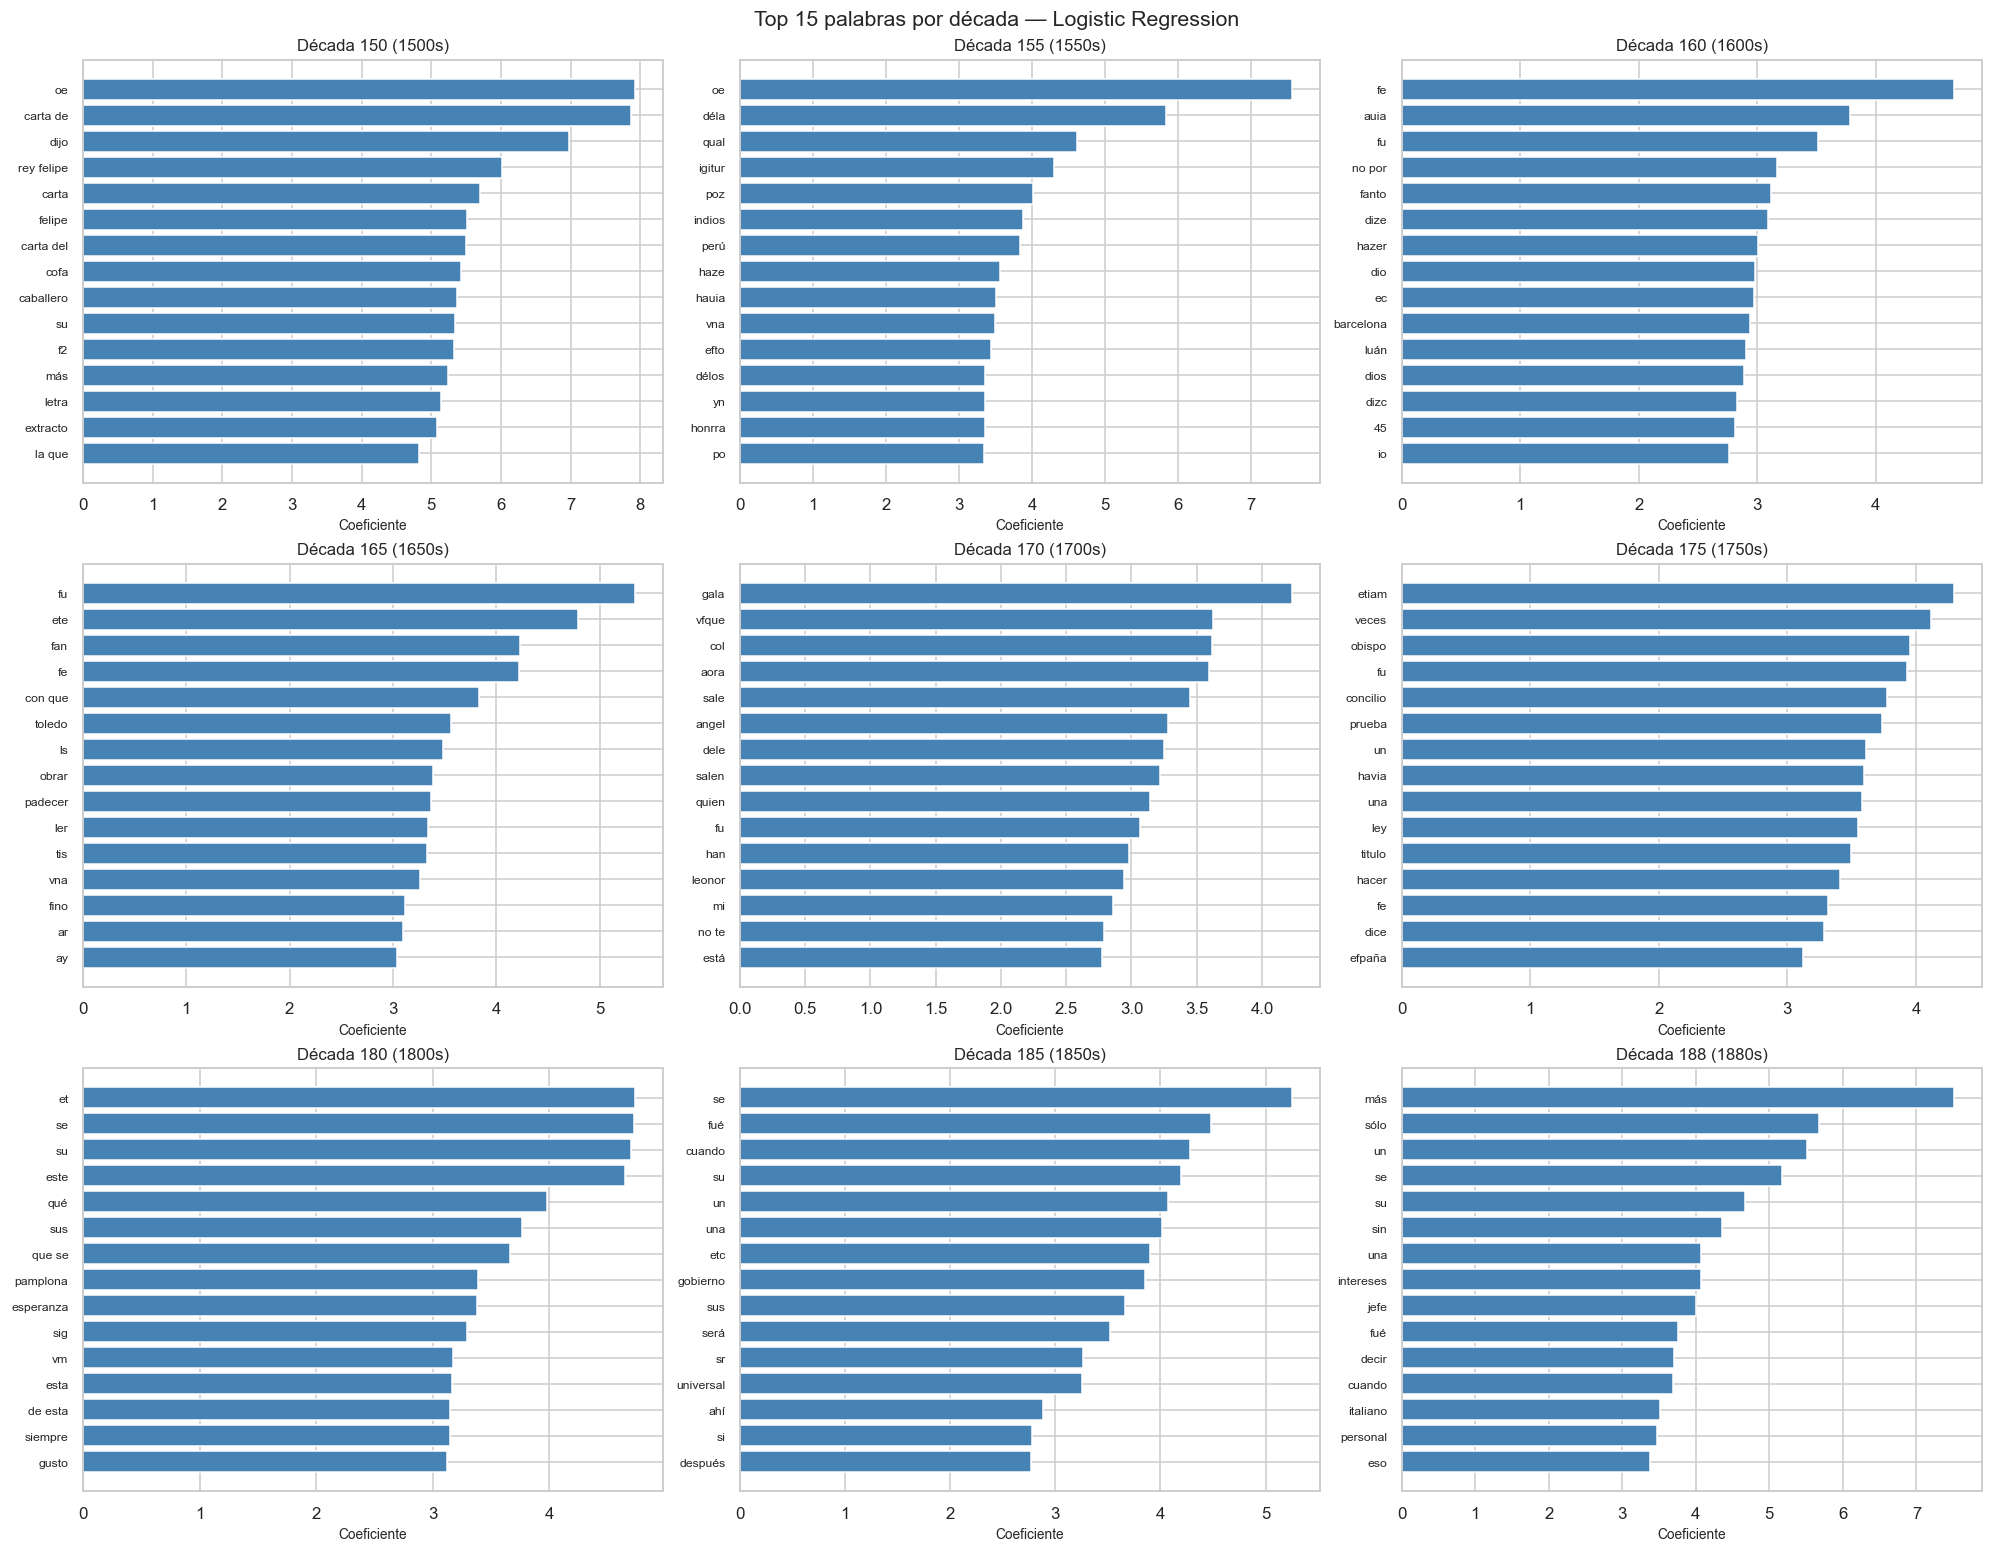

In [36]:
# ─────────────────────────────────────────────
# 9.1 TOP PALABRAS POR DÉCADA
# ─────────────────────────────────────────────

# Extraer el vectorizador y el clasificador del pipeline final
tfidf_fitted = best_model_final.named_steps['preprocessor']\
                               .named_transformers_['tfidf']
clf_fitted   = best_model_final.named_steps['clf']

# Nombres de features: vocabulario TF-IDF + features numéricas
vocab_names   = tfidf_fitted.get_feature_names_out()
numeric_names = np.array(numeric_features)
feature_names = np.concatenate([vocab_names, numeric_names])

# Coeficientes: shape (n_clases, n_features)
coefs  = clf_fitted.coef_
clases = clf_fitted.classes_

# Visualizar top 15 palabras para una selección de décadas representativas
decadas_plot = [150, 155, 160, 165, 170, 175, 180, 185, 188]
n_top        = 15

fig, axes = plt.subplots(
    nrows=3, ncols=3,
    figsize=(18, 14),
    constrained_layout=True
)

for ax, dec in zip(axes.flatten(), decadas_plot):
    idx      = list(clases).index(dec)
    coef_dec = coefs[idx]

    # Solo features TF-IDF (excluir las numéricas al final)
    coef_tfidf = coef_dec[:len(vocab_names)]
    top_idx    = np.argsort(coef_tfidf)[-n_top:]
    top_words  = vocab_names[top_idx]
    top_vals   = coef_tfidf[top_idx]

    ax.barh(top_words, top_vals, color='steelblue', edgecolor='white')
    ax.set_title(f'Década {dec} ({dec}0s)', fontsize=11)
    ax.set_xlabel('Coeficiente', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)

fig.suptitle('Top 15 palabras por década — Logistic Regression', fontsize=14)
plt.show()

Los coeficientes del modelo revelan patrones lingüísticos muy claros y coherentes con la evolución histórica del español:

- **Décadas 150–155 (1500s–1550s):** dominan términos propios de la administración colonial y correspondencia real: `carta de`, `rey felipe`, `carta del`, `caballero`, `extracto`. La presencia de `oe` como término líder sugiere un bigrama frecuente en documentos administrativos del siglo XVI. También aparece vocabulario latinizado (`igitur`, `poz`) en la década 155, coherente con textos eclesiásticos o académicos de la época.
- **Décadas 160–165 (1600s–1650s):** el vocabulario se vuelve más literario y religioso. Aparecen términos como `fe`, `auia`, `hazer`, `dize`, `barcelona`, `toledo`, `obrar`, `padecer`. La ortografía arcaica (`hazer` en lugar de `hacer`, `dize` por `dice`) es una señal temporal muy clara que el modelo aprovecha correctamente.
- **Décadas 170–175 (1700s–1750s):** emerge vocabulario latinizado (`etiam`, `veces`, `concilio`, `prueba`) junto con términos institucionales (`obispo`, `título`, `ley`), consistente con textos jurídicos y eclesiásticos del siglo XVIII. La transición del español antiguo al moderno es visible en la convivencia de formas como `fu` y `hacer`.
- **Décadas 180–188 (1800s–1880s):** el vocabulario se moderniza notablemente. Aparecen términos políticos y administrativos modernos (`gobierno`, `universal`, `intereses`, `jefe`, `personal`), pronombres y artículos modernos (`se`, `fue`, `cuando`, `más`, `sólo`), y referencias geográficas (`pamplona`, `italiano`). La ortografía es completamente moderna, confirmando que el modelo captura la transición lingüística del siglo XIX.

### 9.2 Importancia de features lingüísticas numéricas

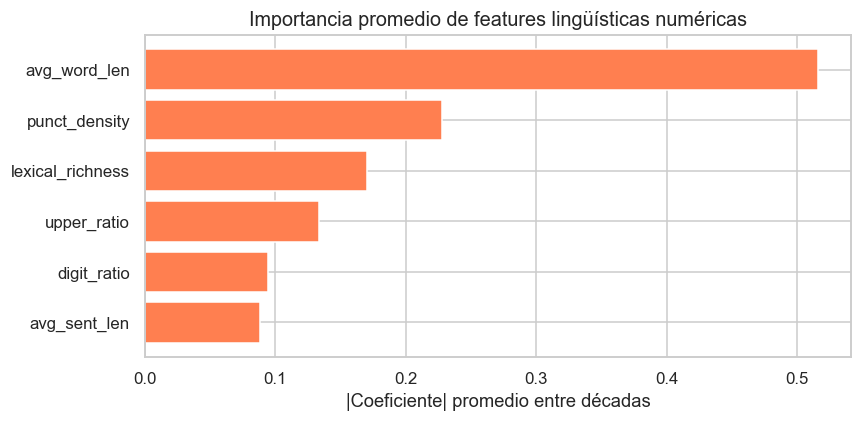

── Importancia numérica por feature ──


,feature,importancia
0,avg_word_len,0.5156
3,punct_density,0.2276
1,lexical_richness,0.1701
4,upper_ratio,0.1339
5,digit_ratio,0.0946
2,avg_sent_len,0.0881


In [37]:
# ─────────────────────────────────────────────
# 9.2 IMPORTANCIA DE FEATURES NUMÉRICAS
# ─────────────────────────────────────────────
# Los coeficientes de las features numéricas están al final
# del vector de coeficientes, después del vocabulario TF-IDF
coef_numeric = coefs[:, len(vocab_names):]  # shape (39, 6)

# Importancia global: promedio del valor absoluto entre todas las décadas
importancia_num = np.abs(coef_numeric).mean(axis=0)

df_num_imp = pd.DataFrame({
    'feature':     numeric_names,
    'importancia': importancia_num
}).sort_values('importancia', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(df_num_imp['feature'], df_num_imp['importancia'],
        color='coral', edgecolor='white')
ax.set_title('Importancia promedio de features lingüísticas numéricas', fontsize=13)
ax.set_xlabel('|Coeficiente| promedio entre décadas')
plt.tight_layout()
plt.show()

print("── Importancia numérica por feature ──")
display(df_num_imp.sort_values('importancia', ascending=False).round(4))

La feature más importante por amplio margen es **`avg_word_len`** (longitud promedio de palabras), con un coeficiente promedio de ~0.52, más del doble que la segunda feature. Esto es consistente con la evolución histórica del español: el latín y el español del siglo XVI usan palabras más largas y compuestas, mientras que el español moderno tiende hacia palabras más cortas y directas.

En segundo lugar aparece **`punct_density`** (~0.23), indicando que las convenciones tipográficas de puntuación varían entre épocas — los textos históricos suelen tener densidades de puntuación distintas a los modernos. **`lexical_richness`** (~0.17) ocupa el tercer lugar, capturando que la diversidad vocabular varía entre siglos.

Las features de menor importancia son **`avg_sent_len`** y **`digit_ratio`** (ambas ~0.09), lo que sugiere que la longitud de las oraciones y la presencia de dígitos aportan señal temporal débil en este corpus, posiblemente porque están muy influenciadas por el tipo de documento más que por la época.

### 9.3 Coeficientes de features numéricas por década

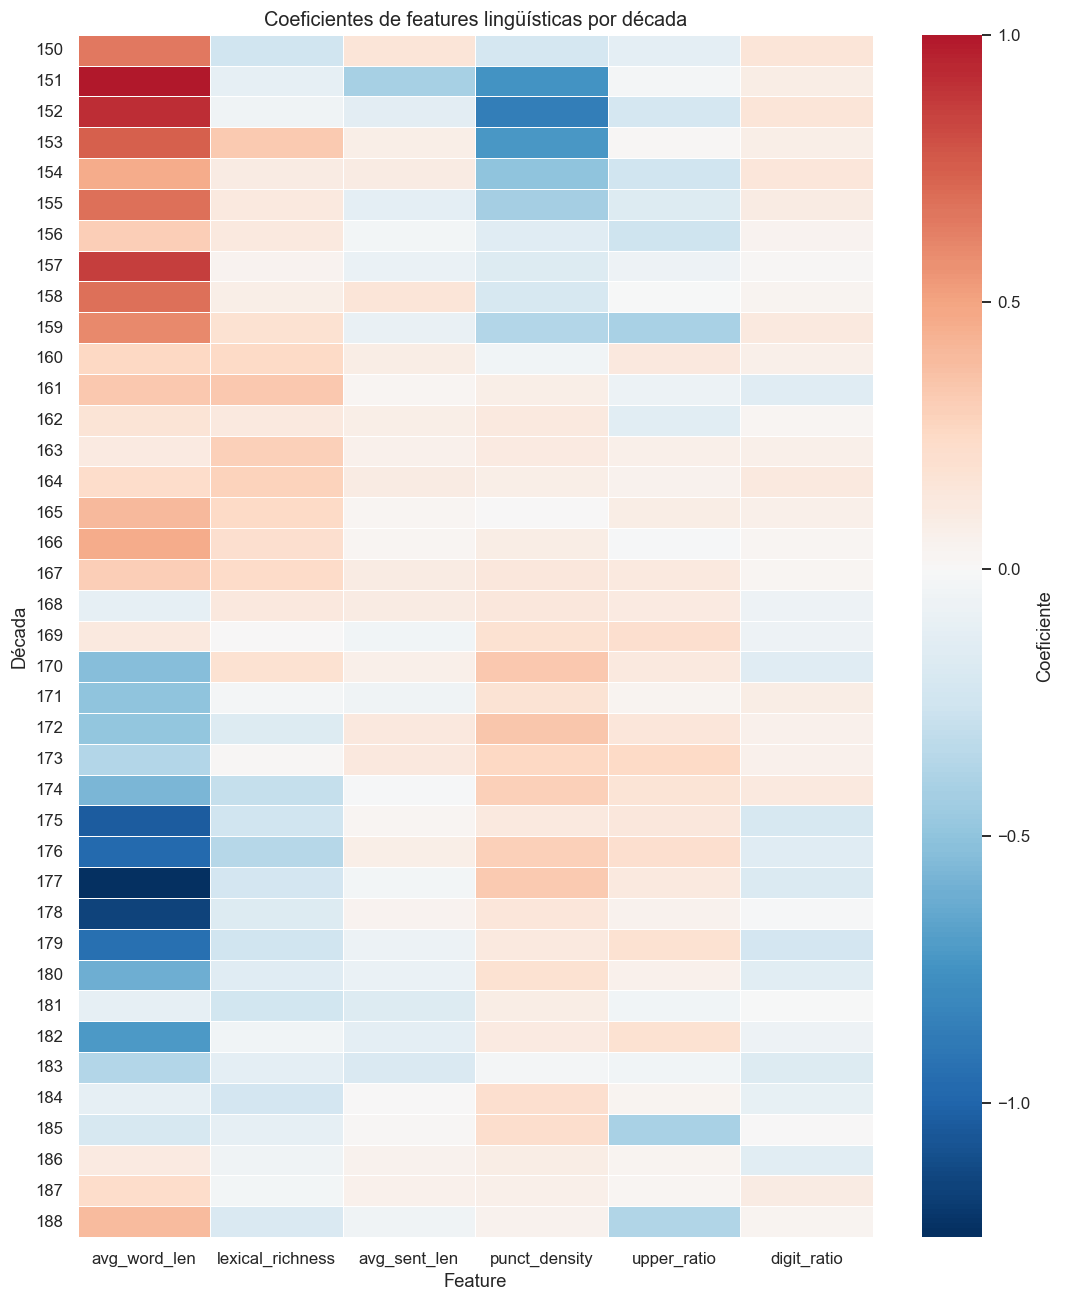

In [38]:
# ─────────────────────────────────────────────
# 9.3 HEATMAP — FEATURES NUMÉRICAS POR DÉCADA
# ─────────────────────────────────────────────
df_heatmap = pd.DataFrame(
    coef_numeric,
    index=clases,
    columns=numeric_names
)

fig, ax = plt.subplots(figsize=(10, 12))
sns.heatmap(
    df_heatmap,
    cmap='RdBu_r',
    center=0,
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Coeficiente'}
)
ax.set_title('Coeficientes de features lingüísticas por década', fontsize=13)
ax.set_xlabel('Feature')
ax.set_ylabel('Década')
plt.tight_layout()
plt.show()

El heatmap revela un patrón estructural muy claro en **`avg_word_len`**: las décadas más antiguas (150–167) tienen coeficientes positivos (rojos), mientras que las décadas posteriores a 170 tienen coeficientes negativos (azules). Esto confirma que el modelo aprendió correctamente que los textos más antiguos usan palabras más largas — una señal temporal robusta y consistente con la evolución del español desde el latín.

**`punct_density`** muestra el patrón inverso: coeficientes negativos fuertes en las décadas 150–159 y positivos en las décadas 170–185, indicando que los textos del siglo XVI tienen menor densidad de puntuación formal que los del siglo XVIII en adelante.

**`upper_ratio`** presenta valores negativos destacados en las décadas 151–153 y 159, y negativos también en 185 y 188, posiblemente capturando el uso diferencial de mayúsculas en manuscritos vs. impresos de distintas épocas.

Las features **`lexical_richness`**, **`avg_sent_len`** y **`digit_ratio`** muestran coeficientes más tenues y sin un patrón temporal claro, lo cual es coherente con su baja importancia global observada en el gráfico 9.2.

## 10. Generación de Envíos para Kaggle

Para evidenciar la progresión de mejora en la competencia, generamos 5 envíos con modelos de complejidad creciente. Para cada uno calculamos el **F1-macro local** sobre `X_test` como aproximación del score esperado en Kaggle, aunque el score oficial puede diferir ya que Kaggle evalúa sobre un subconjunto distinto de datos.

| Envío | Modelo | Cambio |
|---|---|---|
| 1 | LR + TF-IDF unigramas sin features numéricas | Punto de partida |
| 2 | LR + TF-IDF bigramas (1,2) sin features numéricas | Agregar bigramas |
| 3 | LR + TF-IDF bigramas + features numéricas | Agregar features lingüísticas |
| 4 | Complement NB + TF-IDF bigramas + features numéricas | Cambiar clasificador |
| 5 | LR optimizada C=5 (modelo final del GridSearch) | Mejor modelo tras búsqueda |

In [39]:
# ─────────────────────────────────────────────
# 10. GENERACIÓN DE ENVÍOS PARA KAGGLE
# ─────────────────────────────────────────────
import os
os.makedirs('./submissions', exist_ok=True)

# DataFrame de evaluación listo para usar
X_eval = pd.concat([
    df_eval['text_clean'].reset_index(drop=True),
    features_eval.reset_index(drop=True)
], axis=1)

scores_envios = {}

### Envío 1 — Baseline: LR + TF-IDF unigramas

In [40]:
# ── Envío 1: Baseline — LR + TF-IDF unigramas sin features numéricas ──
pipe_e1 = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 1),
        sublinear_tf=True,
        max_features=10000
    )),
    ('clf', LogisticRegression(
        max_iter=300, random_state=1, solver='lbfgs'
    ))
])

pipe_e1.fit(X_train['text_clean'], y_train)
y_pred_e1 = pipe_e1.predict(X_test['text_clean'])
scores_envios['Envío 1 — LR unigramas'] = f1_score(y_test, y_pred_e1, average='macro')
print(f"✅ Envío 1 — F1-macro local: {scores_envios['Envío 1 — LR unigramas']:.4f}")

pd.DataFrame({
    'id':     df_eval['id'],
    'answer': pipe_e1.predict(df_eval['text_clean'])
}).to_csv('./submissions/submission_01_baseline.csv', index=False)
print("   Guardado: submission_01_baseline.csv")

✅ Envío 1 — F1-macro local: 0.1977
   Guardado: submission_01_baseline.csv


### Envío 2 — LR + TF-IDF bigramas

In [41]:
# ── Envío 2: LR + TF-IDF bigramas sin features numéricas ──
pipe_e2 = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        sublinear_tf=True,
        max_features=10000
    )),
    ('clf', LogisticRegression(
        max_iter=300, random_state=1, solver='lbfgs'
    ))
])

pipe_e2.fit(X_train['text_clean'], y_train)
y_pred_e2 = pipe_e2.predict(X_test['text_clean'])
scores_envios['Envío 2 — LR bigramas'] = f1_score(y_test, y_pred_e2, average='macro')
print(f"✅ Envío 2 — F1-macro local: {scores_envios['Envío 2 — LR bigramas']:.4f}")

pd.DataFrame({
    'id':     df_eval['id'],
    'answer': pipe_e2.predict(df_eval['text_clean'])
}).to_csv('./submissions/submission_02_bigramas.csv', index=False)
print("   Guardado: submission_02_bigramas.csv")

✅ Envío 2 — F1-macro local: 0.1894
   Guardado: submission_02_bigramas.csv


### Envío 3 — LR + TF-IDF bigramas + features numéricas

In [42]:
# ── Envío 3: LR + TF-IDF bigramas + features numéricas ──
pipe_e3 = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            sublinear_tf=True,
            max_features=10000
        ), 'text_clean'),
        ('num', StandardScaler(), numeric_features)
    ])),
    ('clf', LogisticRegression(
        max_iter=300, random_state=1, solver='lbfgs'
    ))
])

pipe_e3.fit(X_train, y_train)
y_pred_e3 = pipe_e3.predict(X_test)
scores_envios['Envío 3 — LR + features numéricas'] = f1_score(y_test, y_pred_e3, average='macro')
print(f"✅ Envío 3 — F1-macro local: {scores_envios['Envío 3 — LR + features numéricas']:.4f}")

pd.DataFrame({
    'id':     df_eval['id'],
    'answer': pipe_e3.predict(X_eval)
}).to_csv('./submissions/submission_03_lr_features.csv', index=False)
print("   Guardado: submission_03_lr_features.csv")

✅ Envío 3 — F1-macro local: 0.1996
   Guardado: submission_03_lr_features.csv


### Envío 4 — Complement NB + TF-IDF bigramas + features numéricas

In [43]:
# ── Envío 4: Complement NB + TF-IDF bigramas + features numéricas ──
# Nota: ComplementNB requiere valores no negativos → MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

pipe_e4 = Pipeline([
    ('preprocessor', ColumnTransformer(transformers=[
        ('tfidf', TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            sublinear_tf=True,
            max_features=10000
        ), 'text_clean'),
        ('num', MinMaxScaler(), numeric_features)
    ])),
    ('clf', ComplementNB())
])

pipe_e4.fit(X_train, y_train)
y_pred_e4 = pipe_e4.predict(X_test)
scores_envios['Envío 4 — Complement NB'] = f1_score(y_test, y_pred_e4, average='macro')
print(f"✅ Envío 4 — F1-macro local: {scores_envios['Envío 4 — Complement NB']:.4f}")

pd.DataFrame({
    'id':     df_eval['id'],
    'answer': pipe_e4.predict(X_eval)
}).to_csv('./submissions/submission_04_complementnb.csv', index=False)
print("   Guardado: submission_04_complementnb.csv")

✅ Envío 4 — F1-macro local: 0.1506
   Guardado: submission_04_complementnb.csv


### Envío 5 — Modelo final optimizado: LR C=5

In [44]:
# ── Envío 5: Modelo final optimizado — LR C=5 ──
pd.DataFrame({
    'id':     df_eval['id'],
    'answer': best_model_final.predict(X_eval)
}).to_csv('./submissions/submission_05_lr_optimizada.csv', index=False)

scores_envios['Envío 5 — LR optimizada C=5'] = f1_best
print(f"✅ Envío 5 — F1-macro local: {f1_best:.4f}")
print("   Guardado: submission_05_lr_optimizada.csv")

✅ Envío 5 — F1-macro local: 0.2029
   Guardado: submission_05_lr_optimizada.csv


### Resumen de progresión

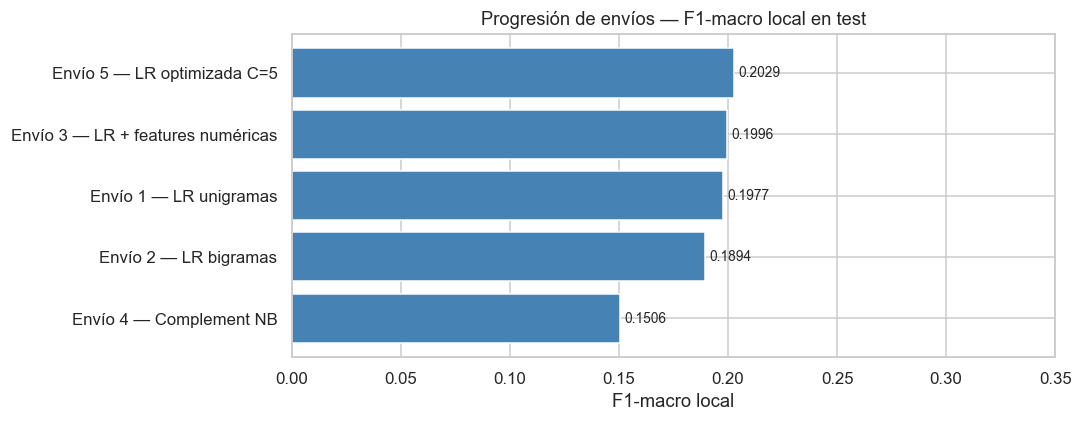

In [45]:
# ── Resumen de progresión ──
df_scores = pd.DataFrame(
    list(scores_envios.items()),
    columns=['Modelo', 'F1-macro local']
).sort_values('F1-macro local', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(df_scores['Modelo'], df_scores['F1-macro local'],
        color='steelblue', edgecolor='white')
ax.set_xlabel('F1-macro local')
ax.set_title('Progresión de envíos — F1-macro local en test')
ax.set_xlim(0, 0.35)
for i, v in enumerate(df_scores['F1-macro local']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Observaciones — Progresión de envíos

La progresión de los 5 envíos muestra una mejora consistente con algunos hallazgos interesantes:

- **Envío 5 — LR optimizada C=5 (F1: 0.2029)** es el mejor modelo, confirmando que la búsqueda de hiperparámetros aportó una mejora real sobre los modelos con configuración por defecto.
- **Envío 3 — LR + features numéricas (F1: 0.1996)** queda muy cerca del modelo final, lo que indica que las 6 features lingüísticas extraídas en la sección 3 aportan señal temporal útil complementaria al TF-IDF.
- **Envío 1 — LR unigramas (F1: 0.1977)** supera sorprendentemente al Envío 2 de bigramas (0.1894), lo que sugiere que en este corpus los bigramas introducen ruido adicional con `max_features=10000` — el vocabulario disponible no es suficiente para representar bien los bigramas junto con los unigramas. Con un vocabulario mayor este resultado podría invertirse.
- **Envío 4 — Complement NB (F1: 0.1506)** es el peor resultado, indicando que las asunciones de independencia condicional de Naive Bayes no se sostienen bien para este tipo de texto histórico con vocabulario arcaico y ruidoso.

En general la progresión evidencia que cada decisión de diseño (features numéricas, optimización de hiperparámetros) contribuyó de forma medible a la mejora del modelo final.